In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import mne
import numpy as np
import pandas as pd

In [3]:
bipolar_pairs = [
    ('EEG Fp1-REF', 'EEG F7-REF'),
    ('EEG F7-REF',  'EEG T3-REF'),
    ('EEG T3-REF',  'EEG T5-REF'),
    ('EEG T5-REF',  'EEG O1-REF'),
    ('EEG Fp1-REF', 'EEG F3-REF'),
    ('EEG F3-REF',  'EEG C3-REF'),
    ('EEG C3-REF',  'EEG P3-REF'),
    ('EEG P3-REF',  'EEG O1-REF'),
    ('EEG Fz-REF',  'EEG Cz-REF'),
    ('EEG Cz-REF',  'EEG Pz-REF'),
    ('EEG Fp2-REF', 'EEG F4-REF'),
    ('EEG F4-REF',  'EEG C4-REF'),
    ('EEG C4-REF',  'EEG P4-REF'),
    ('EEG P4-REF',  'EEG O2-REF'),
    ('EEG Fp2-REF', 'EEG F8-REF'),
    ('EEG F8-REF',  'EEG T4-REF'),
    ('EEG T4-REF',  'EEG T6-REF'),
    ('EEG T6-REF',  'EEG O2-REF'),
]

desired_order = [
    'Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2',
    'Fp1-F3', 'F3-C3', 'C3-P3', 'P3-O1',
    'Fp2-F8', 'F8-T4', 'T4-T6', 'T6-O2',
    'Fp1-F7', 'F7-T3', 'T3-T5', 'T5-O1',
    'Fz-Cz', 'Cz-Pz',
]

def normalize_channel(ch):
    return ch.strip().upper()

bipolar_pairs = [(normalize_channel(a), normalize_channel(b)) for a, b in bipolar_pairs]


def pair_name(pair):
    left = pair[0].replace('EEG ', '').replace('-REF', '')
    right = pair[1].replace('EEG ', '').replace('-REF', '')
    return f"{left}-{right}".upper()  # Ensure uppercase for consistency

name_to_pair = {pair_name(p): p for p in bipolar_pairs}

# print("Available pairs in name_to_pair:")
# for name in name_to_pair.keys():
    # print(name)

desired_order_upper = [name.upper() for name in desired_order]

for name in desired_order_upper:
    if name not in name_to_pair:
        print(f"Warning: '{name}' not found in name_to_pair")

reordered_pairs = [name_to_pair[name] for name in desired_order_upper if name in name_to_pair]

def make_ch_names(pairs):
    def pretty(ch):
        ch = ch.replace('EEG ', '').replace('-REF', '')
        return ch.capitalize()
    return [f"{pretty(a)}-{pretty(b)}" for a, b in pairs]

ch_names = make_ch_names(reordered_pairs)

# for name, pair, pretty_name in zip(desired_order_upper, reordered_pairs, ch_names):
    # print(f"{name}: {pair} -> {pretty_name}")
anode = [a for a, _ in bipolar_pairs]
cathode = [b for _, b in bipolar_pairs]
ch_names = make_ch_names(reordered_pairs)
def getArray(filename: str):
    raw = mne.io.read_raw_edf(filename, preload=True)
    raw.rename_channels(lambda ch: ch.upper())
    drop_candidates = ['ECG EKG', 'RESP EFFORT','ECG EKG-REF','RESP EFFORT-REF']
    available = set(raw.ch_names)
    to_drop = [ch for ch in drop_candidates if ch in available]
    if to_drop:
        raw.drop_channels(to_drop)
    raw = mne.set_bipolar_reference(raw, anode=anode, cathode=cathode, ch_name=ch_names, copy=True)
    array = raw.get_data()
    # raw.plot()
    return array

In [4]:

annotations = pd.read_excel('C:/bt23ece064/dataset/annot.xlsx')

In [5]:
import os
eeg_set = []
for i in range(1, 80):
    filepath = f'C:/bt23ece064/dataset/eeg{i}.edf'
    if os.path.exists(filepath):
        try:
            eeg = getArray(filepath)
            eeg_set.append(eeg)
        except ValueError as e:
            print(f"Error in file: {filepath}")
            print(e)

Extracting EDF parameters from C:\bt23ece064\dataset\eeg1.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1790207  =      0.000 ...  6992.996 secs...
EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=18, n_times=1790208
    Range : 0 ... 1790207 =      0.000 ...  6992.996 secs
Ready.
Added the following bipolar channels:
Fp2-F4, F4-C4, C4-P4, P4-O2, Fp1-F3, F3-C3, C3-P3, P3-O1, Fp2-F8, F8-T4, T4-T6, T6-O2, Fp1-F7, F7-T3, T3-T5, T5-O1, Fz-Cz, Cz-Pz
Extracting EDF parameters from C:\bt23ece064\dataset\eeg2.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 962815  =      0.000 ...  3760.996 secs...


C:\Users\Admin\AppData\Local\Temp\ipykernel_13028\1992953508.py:69: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(filename, preload=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_13028\1992953508.py:69: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(filename, preload=True)


EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=18, n_times=962816
    Range : 0 ... 962815 =      0.000 ...  3760.996 secs
Ready.
Added the following bipolar channels:
Fp2-F4, F4-C4, C4-P4, P4-O2, Fp1-F3, F3-C3, C3-P3, P3-O1, Fp2-F8, F8-T4, T4-T6, T6-O2, Fp1-F7, F7-T3, T3-T5, T5-O1, Fz-Cz, Cz-Pz
Extracting EDF parameters from C:\bt23ece064\dataset\eeg3.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1129471  =      0.000 ...  4411.996 secs...


C:\Users\Admin\AppData\Local\Temp\ipykernel_13028\1992953508.py:69: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(filename, preload=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_13028\1992953508.py:69: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(filename, preload=True)


EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=18, n_times=1129472
    Range : 0 ... 1129471 =      0.000 ...  4411.996 secs
Ready.
Added the following bipolar channels:
Fp2-F4, F4-C4, C4-P4, P4-O2, Fp1-F3, F3-C3, C3-P3, P3-O1, Fp2-F8, F8-T4, T4-T6, T6-O2, Fp1-F7, F7-T3, T3-T5, T5-O1, Fz-Cz, Cz-Pz
Extracting EDF parameters from C:\bt23ece064\dataset\eeg4.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 876799  =      0.000 ...  3424.996 secs...


...

EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=18, n_times=1073408
    Range : 0 ... 1073407 =      0.000 ...  4192.996 secs
Ready.
Added the following bipolar channels:
Fp2-F4, F4-C4, C4-P4, P4-O2, Fp1-F3, F3-C3, C3-P3, P3-O1, Fp2-F8, F8-T4, T4-T6, T6-O2, Fp1-F7, F7-T3, T3-T5, T5-O1, Fz-Cz, Cz-Pz
Extracting EDF parameters from C:\bt23ece064\dataset\eeg78.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1272575  =      0.000 ...  4970.996 secs...


C:\Users\Admin\AppData\Local\Temp\ipykernel_13028\1992953508.py:69: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(filename, preload=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_13028\1992953508.py:69: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(filename, preload=True)


EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=18, n_times=1272576
    Range : 0 ... 1272575 =      0.000 ...  4970.996 secs
Ready.
Added the following bipolar channels:
Fp2-F4, F4-C4, C4-P4, P4-O2, Fp1-F3, F3-C3, C3-P3, P3-O1, Fp2-F8, F8-T4, T4-T6, T6-O2, Fp1-F7, F7-T3, T3-T5, T5-O1, Fz-Cz, Cz-Pz
Extracting EDF parameters from C:\bt23ece064\dataset\eeg79.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 844031  =      0.000 ...  3296.996 secs...


C:\Users\Admin\AppData\Local\Temp\ipykernel_13028\1992953508.py:69: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(filename, preload=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_13028\1992953508.py:69: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(filename, preload=True)


EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=18, n_times=844032
    Range : 0 ... 844031 =      0.000 ...  3296.996 secs
Ready.
Added the following bipolar channels:
Fp2-F4, F4-C4, C4-P4, P4-O2, Fp1-F3, F3-C3, C3-P3, P3-O1, Fp2-F8, F8-T4, T4-T6, T6-O2, Fp1-F7, F7-T3, T3-T5, T5-O1, Fz-Cz, Cz-Pz


In [6]:

annotations = annotations.sort_values(by=['FILE ID','Start'], ascending=[True,True])
annotations = annotations.dropna(axis=0)
     
     

import numpy as np


seizured_segments = [
    [np.zeros_like(channel, dtype=float) for channel in patient_eeg] 
    for patient_eeg in eeg_set
]
non_seizured_segments = [
    [np.zeros_like(channel, dtype=float) for channel in patient_eeg] 
    for patient_eeg in eeg_set
]


unordered_seizured_segments = []
unordered_non_seizured_segments = []

channel_cols = ['Fp2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'Fp1-F3', 'F3-C3', 'C3-P3',
                'Fp2-F8', 'F8-T4', 'T4-T6', 'T6-O2', 'Fp1-F7', 'F7-T3', 'T3-T5', 
                'T5-O1', 'Fz-Cz', 'Cz-Pz']

print(f"Starting processing {len(annotations)} annotations...")
print(f"Total patients in eeg_set: {len(eeg_set)}")


for i in range(len(annotations)):
    patient = int(annotations['FILE ID'].iloc[i] - 1)
    start = int(annotations['Start'].iloc[i] * 256) 
    stop = int(annotations['Stop'].iloc[i] * 256)
    
    
    print(f"Processing annotation {i+1}/{len(annotations)} - Patient {patient+1}, Time: {annotations['Start'].iloc[i]:.1f}s-{annotations['Stop'].iloc[i]:.1f}s")
    
    seizure_count = 0
    non_seizure_count = 0
    
    for ch_idx, col in enumerate(channel_cols):
        if ch_idx < len(eeg_set[patient]): 
            if annotations[col].iloc[i] == 1: 
                seizured_segments[patient][ch_idx][start:stop] = eeg_set[patient][ch_idx][start:stop]
                non_seizured_segments[patient][ch_idx][start:stop] = 0
                unordered_seizured_segments.append(eeg_set[patient][ch_idx][start:stop])
                seizure_count += 1
            else:  
                seizured_segments[patient][ch_idx][start:stop] = 0
                non_seizured_segments[patient][ch_idx][start:stop] = eeg_set[patient][ch_idx][start:stop]
                unordered_non_seizured_segments.append(eeg_set[patient][ch_idx][start:stop])
                non_seizure_count += 1
    
    print(f"  Annotation {i+1}: {seizure_count} seizure channels, {non_seizure_count} non-seizure channels")

print("\nProcessing complete!")
print(f"Total annotations processed: {len(annotations)}")

Starting processing 364 annotations...
Total patients in eeg_set: 79
Processing annotation 1/364 - Patient 1, Time: 104.0s-122.0s
  Annotation 1: 2 seizure channels, 15 non-seizure channels
Processing annotation 2/364 - Patient 1, Time: 349.0s-428.0s
  Annotation 2: 2 seizure channels, 15 non-seizure channels
Processing annotation 3/364 - Patient 1, Time: 760.0s-779.0s
  Annotation 3: 2 seizure channels, 15 non-seizure channels
Processing annotation 4/364 - Patient 1, Time: 956.0s-965.0s
  Annotation 4: 2 seizure channels, 15 non-seizure channels
Processing annotation 5/364 - Patient 1, Time: 973.0s-982.0s
  Annotation 5: 2 seizure channels, 15 non-seizure channels
Processing annotation 6/364 - Patient 1, Time: 1179.0s-1195.0s
  Annotation 6: 2 seizure channels, 15 non-seizure channels
Processing annotation 7/364 - Patient 1, Time: 1601.0s-1613.0s
  Annotation 7: 1 seizure channels, 16 non-seizure channels
Processing annotation 8/364 - Patient 1, Time: 1622.0s-1632.0s
  Annotation 8: 2

In [17]:
import pywt

wavelet_list = pywt.wavelist(kind='discrete')

In [18]:
import random
# EEG indices and train-test split
eeg_idx = [1, 4, 5, 7, 9, 11, 13, 14, 15, 16, 17, 19, 20, 21, 22, 25, 31, 34,
           36, 38, 39, 40, 41, 44, 47, 50, 51, 52, 62, 63, 66, 67, 69, 73, 75,
           76, 77, 78, 79]

random.seed(42)
train_idx = random.sample(eeg_idx, int(len(eeg_idx) * 0.75))
test_idx = [i for i in eeg_idx if i not in train_idx]

In [19]:
import pywt
import pandas as pd
import numpy as np
import random
import gc

# List of wavelets to process
# wavelet_list = ['haar', 'db2', 'sym3', 'coif1', 'bior1.3']  # Or use pywt.wavelist()
train_dfs = []
test_dfs = []
level = 4

def extract_stats(arr):
    return {
        'max': np.max(arr),
        'min': np.min(arr),
        'mean': np.mean(arr),
        'std': np.std(arr)
    }

def extract_features(indices, wavelet_name):
    for i in range(len(annotations)):
        patient_id = int(annotations['FILE ID'].iloc[i])
        if patient_id not in indices:
            continue

        start = int(annotations['Start'].iloc[i] * 256)
        stop = int(annotations['Stop'].iloc[i] * 256)

        for ch_idx, col in enumerate(channel_cols):
            if ch_idx >= len(eeg_set[patient_id - 1]):
                continue

            segment = eeg_set[patient_id - 1][ch_idx][start:stop]
            if len(segment) == 0 or np.all(np.isnan(segment)):
                continue

            label = 1 if annotations[col].iloc[i] == 1 else 0

            try:
                coeffs = pywt.wavedec(segment, wavelet=wavelet_name, level=level)
                coeff_names = ['A4', 'D4', 'D3', 'D2', 'D1']
                coeffs_dict = dict(zip(coeff_names[-len(coeffs):], coeffs))
            except Exception as e:
                print(f"Wavelet '{wavelet_name}' failed on segment: {e}")
                continue

            features = {'label': label, 'wavelet': wavelet_name}
            for name, coeff in coeffs_dict.items():
                stats = extract_stats(coeff)
                for stat_name, value in stats.items():
                    features[f'{name}_{stat_name}'] = value

            yield features  # Memory-efficient streaming yield

# Main loop over wavelets
for wavelet_name in wavelet_list:
    print(f"\n🔍 Processing wavelet: {wavelet_name}")

    # Stream training features
    train_data = pd.DataFrame(extract_features(train_idx, wavelet_name))
    train_dfs.append(train_data)

    # Stream testing features
    test_data = pd.DataFrame(extract_features(test_idx, wavelet_name))
    test_dfs.append(test_data)

    # Optional: write to disk if datasets are large
    # train_data.to_parquet(f'train_{wavelet_name}.parquet')
    # test_data.to_parquet(f'test_{wavelet_name}.parquet')

    # Explicit cleanup
    del train_data, test_data
    gc.collect()  # Flush memory



🔍 Processing wavelet: bior1.1

🔍 Processing wavelet: bior1.3

🔍 Processing wavelet: bior1.5

🔍 Processing wavelet: bior2.2

🔍 Processing wavelet: bior2.4

🔍 Processing wavelet: bior2.6

🔍 Processing wavelet: bior2.8

🔍 Processing wavelet: bior3.1

🔍 Processing wavelet: bior3.3

🔍 Processing wavelet: bior3.5

🔍 Processing wavelet: bior3.7

🔍 Processing wavelet: bior3.9

🔍 Processing wavelet: bior4.4

🔍 Processing wavelet: bior5.5

🔍 Processing wavelet: bior6.8

🔍 Processing wavelet: coif1

🔍 Processing wavelet: coif2

🔍 Processing wavelet: coif3

🔍 Processing wavelet: coif4

🔍 Processing wavelet: coif5

🔍 Processing wavelet: coif6

🔍 Processing wavelet: coif7

🔍 Processing wavelet: coif8

🔍 Processing wavelet: coif9

🔍 Processing wavelet: coif10

🔍 Processing wavelet: coif11

🔍 Processing wavelet: coif12

🔍 Processing wavelet: coif13

🔍 Processing wavelet: coif14

🔍 Processing wavelet: coif15

🔍 Processing wavelet: coif16

🔍 Processing wavelet: coif17

🔍 Processing wavelet: db1

🔍 Proc

In [24]:
temp = train_dfs[0]

In [25]:
temp

,label,wavelet,A4_max,A4_min,A4_mean,A4_std,D4_max,D4_min,D4_mean,D4_std,...,D3_mean,D3_std,D2_max,D2_min,D2_mean,D2_std,D1_max,D1_min,D1_mean,D1_std
0,0,bior1.1,0.000020,-0.000017,1.064141e-06,0.000008,0.000007,-0.000006,9.112881e-08,0.000002,...,-5.806895e-09,0.000001,0.000003,-0.000004,1.589456e-08,1.083417e-06,0.000002,-1.618438e-06,-1.311234e-09,5.787351e-07
1,0,bior1.1,0.000015,-0.000014,6.091590e-07,0.000006,0.000010,-0.000008,-3.298121e-08,0.000002,...,-2.706762e-08,0.000001,0.000003,-0.000003,-8.145962e-09,6.132411e-07,0.000001,-9.710626e-07,-9.834257e-10,3.103374e-07
2,0,bior1.1,0.000020,-0.000021,1.043345e-06,0.000007,0.000006,-0.000007,-1.364283e-08,0.000002,...,1.404894e-09,0.000001,0.000004,-0.000003,-1.655683e-09,7.201988e-07,0.000002,-1.618438e-06,-4.214682e-10,3.488627e-07
3,0,bior1.1,0.000030,-0.000023,-2.247756e-06,0.000009,0.000007,-0.000010,-1.483492e-08,0.000002,...,-2.922179e-08,0.000001,0.000005,-0.000004,-2.251729e-09,1.199168e-06,0.000002,-1.942125e-06,1.685873e-09,6.057451e-07
4,0,bior1.1,0.000024,-0.000018,1.926950e-06,0.000008,0.000006,-0.000005,8.265171e-08,0.000002,...,-3.821311e-08,0.000001,0.000004,-0.000004,7.947280e-10,1.406193e-06,0.000002,-2.157917e-06,-7.492767e-10,7.648302e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4024,0,bior1.1,0.000210,-0.000145,-2.209901e-06,0.000056,0.000074,-0.000073,3.186687e-07,0.000015,...,3.839284e-08,0.000006,0.000019,-0.000020,-2.131608e-08,2.570090e-06,0.000007,-7.808251e-06,3.602292e-09,1.010194e-06
4025,0,bior1.1,0.000293,-0.000242,7.471354e-07,0.000078,0.000053,-0.000105,4.759251e-08,0.000014,...,8.759256e-08,0.000006,0.000014,-0.000016,5.027378e-08,2.959999e-06,0.000010,-1.088423e-05,-2.132936e-09,1.622733e-06
4026,0,bior1.1,0.001297,-0.001497,-5.799979e-05,0.000657,0.000063,-0.000104,-6.441747e-08,0.000017,...,-2.343859e-07,0.000009,0.000058,-0.000039,1.960677e-08,7.288281e-06,0.000035,-4.270877e-05,-3.628361e-08,5.874736e-06
4027,1,bior1.1,0.000203,-0.000307,-2.256555e-06,0.000098,0.000064,-0.000042,-4.050056e-07,0.000011,...,-6.095457e-08,0.000007,0.000030,-0.000047,-5.677585e-08,5.697975e-06,0.000035,-4.401014e-05,-1.502535e-08,4.924884e-06


In [31]:
temp1 = temp[temp['label'] == 1]
temp0 = temp[temp['label'] == 0]

temp1 = temp1.drop(['label','wavelet'], axis=1)
temp0 = temp0.drop(['label','wavelet'], axis=1)

In [33]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


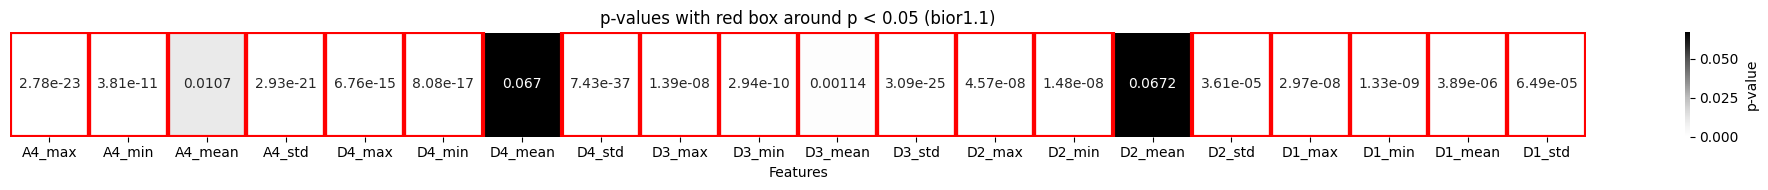

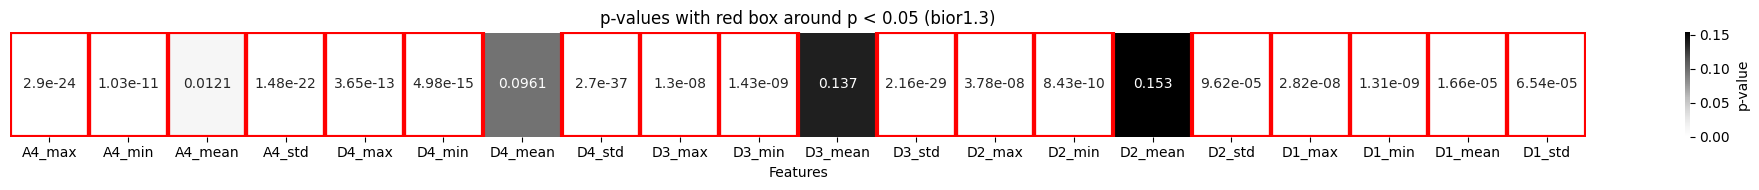

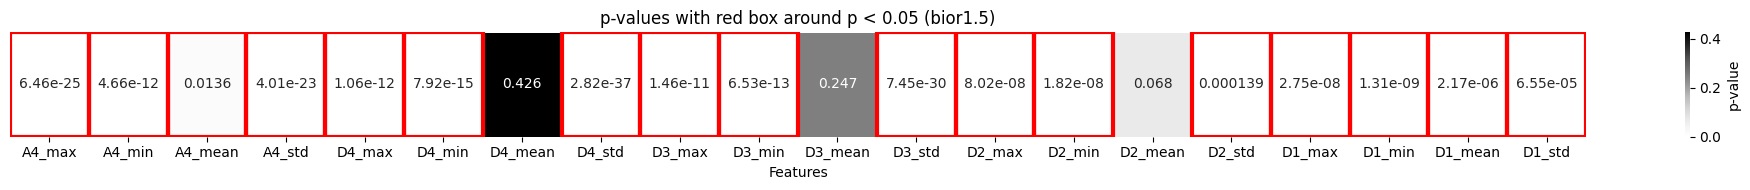

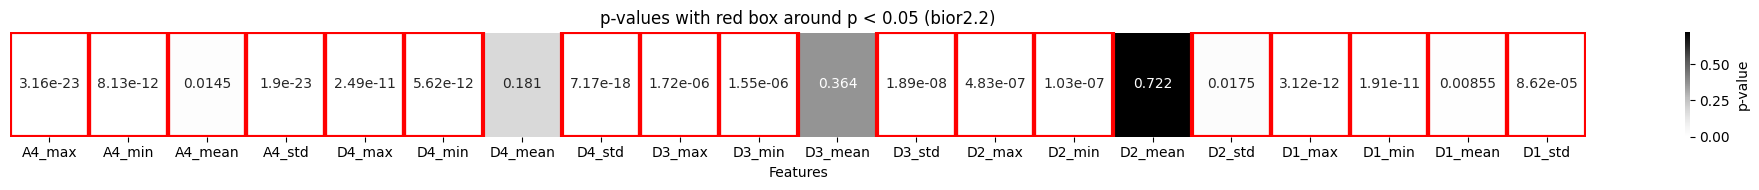

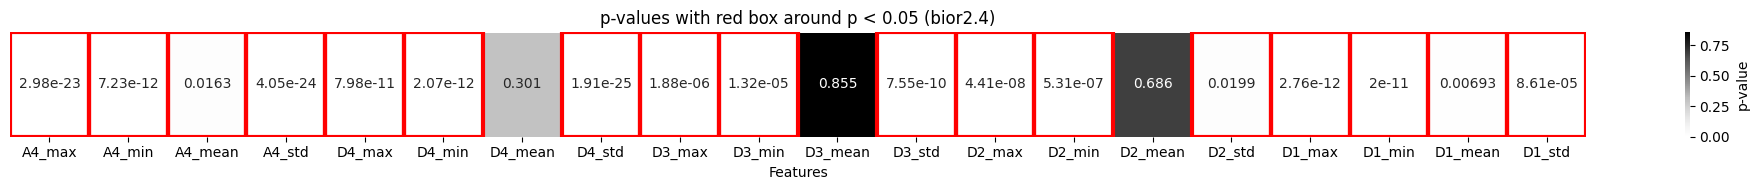

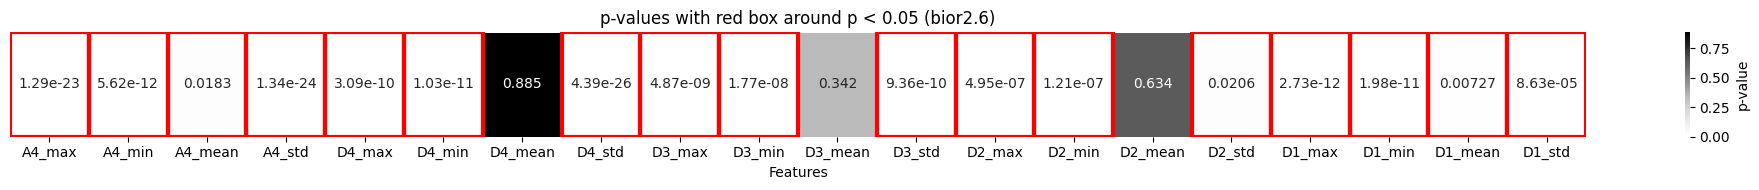

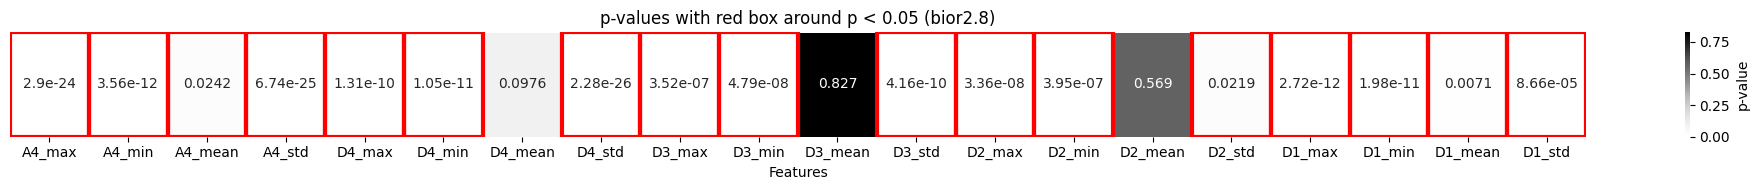

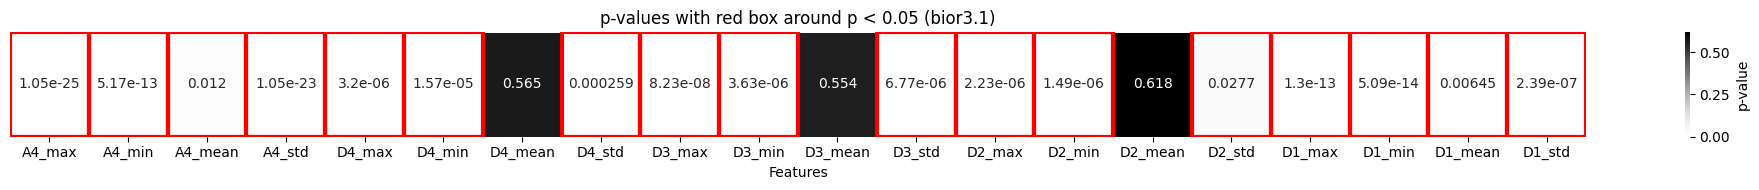

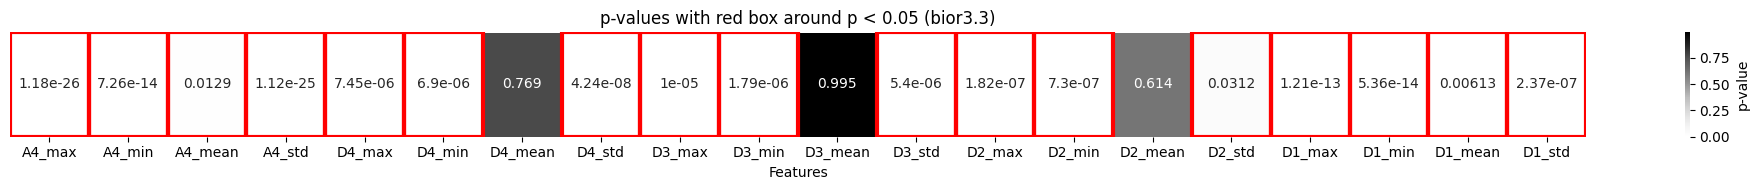

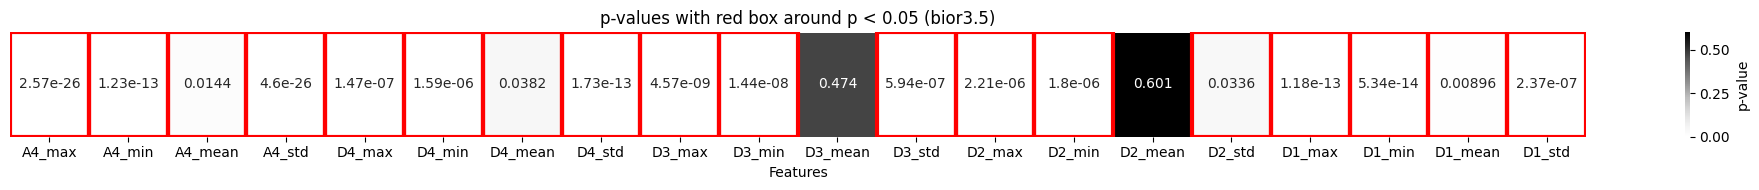

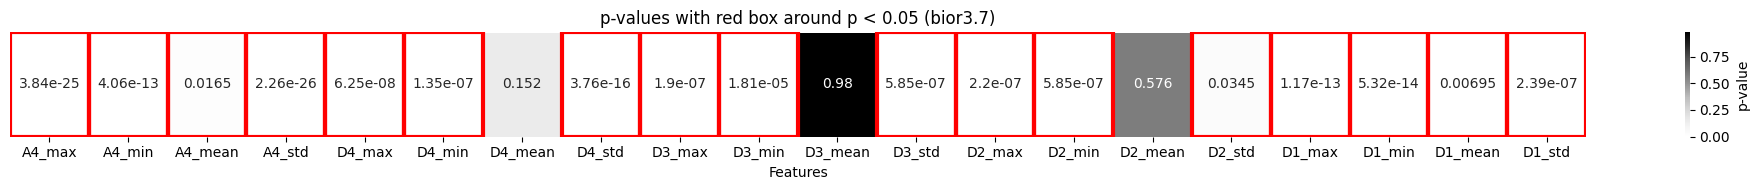

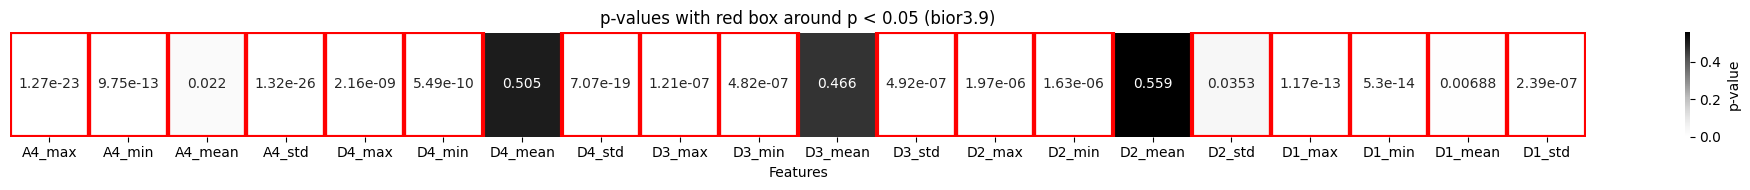

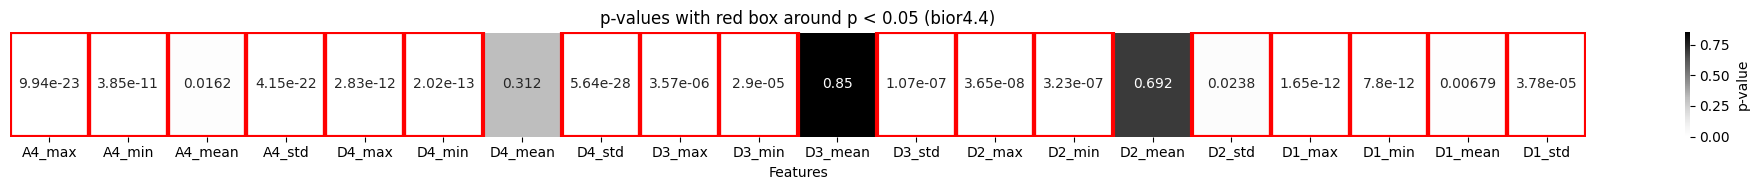

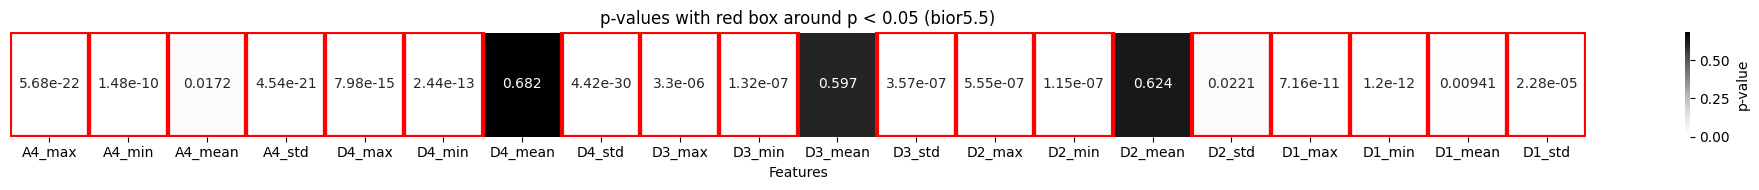

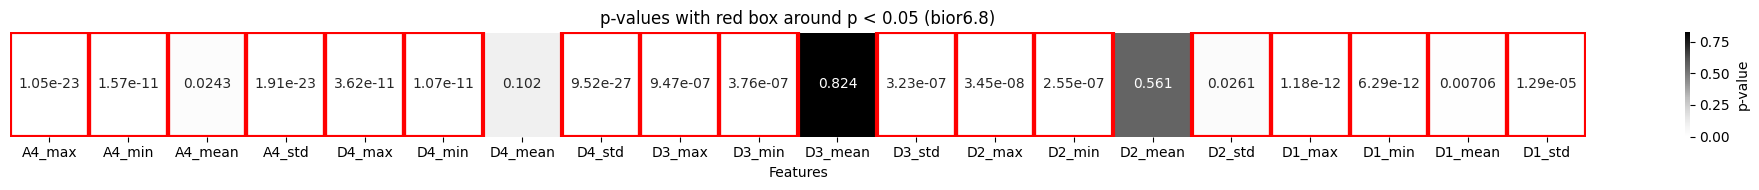

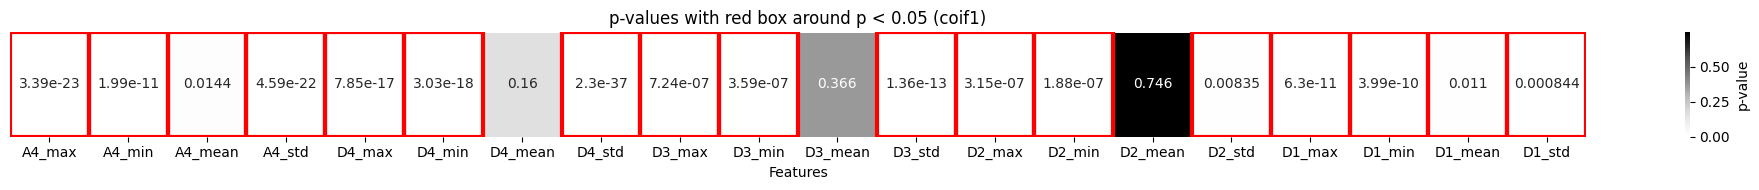

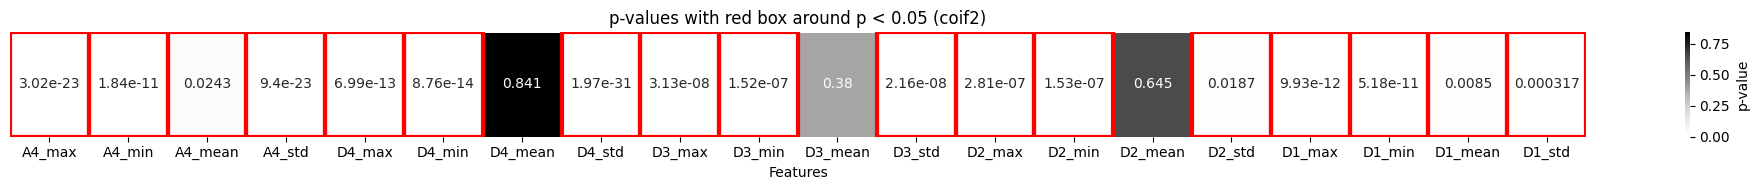

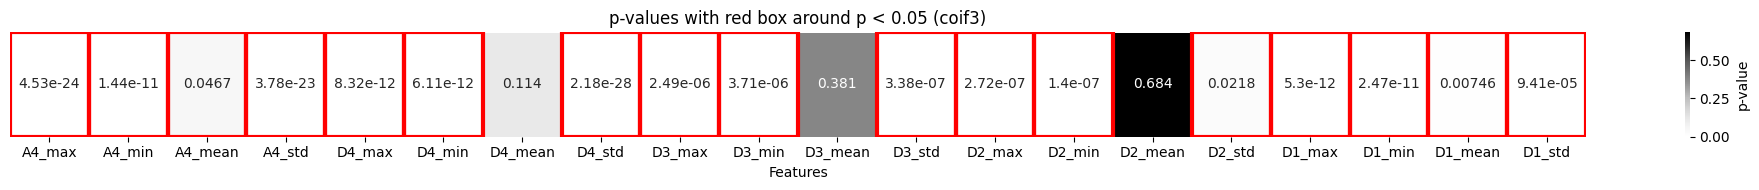

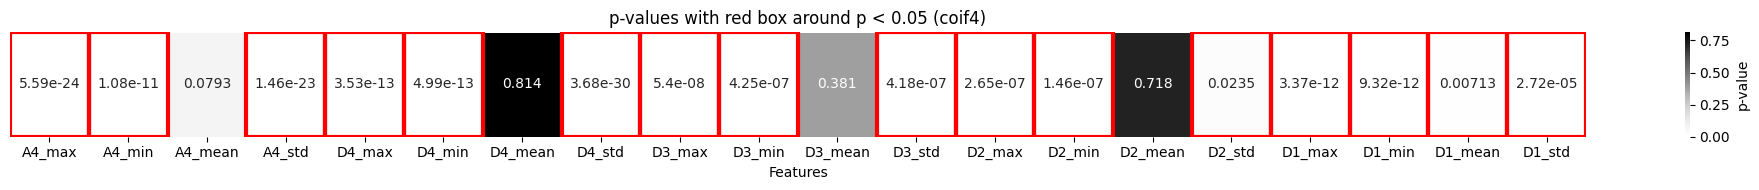

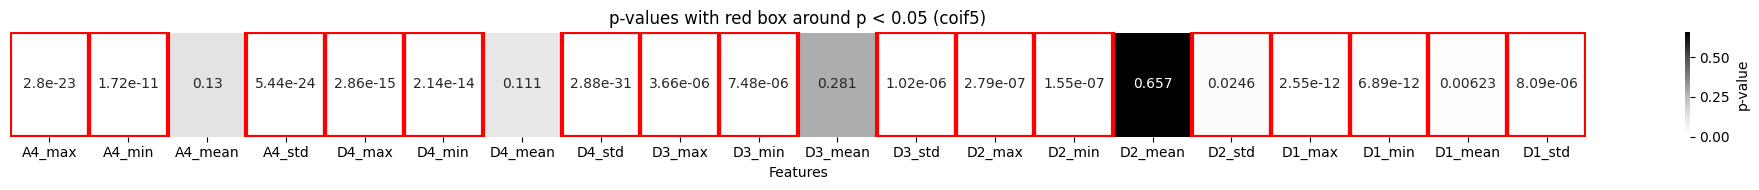

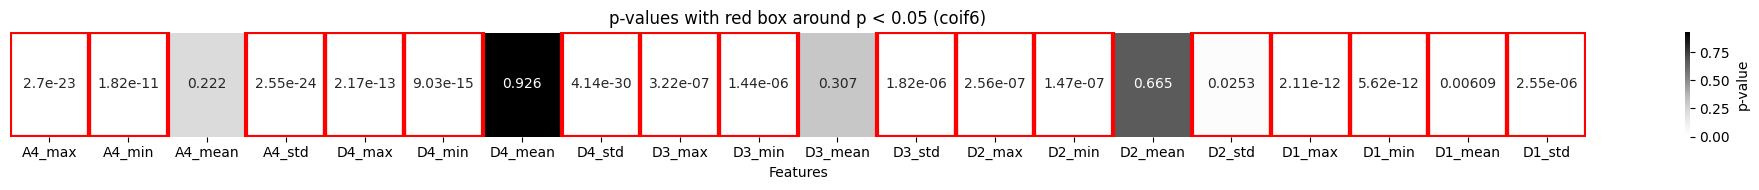

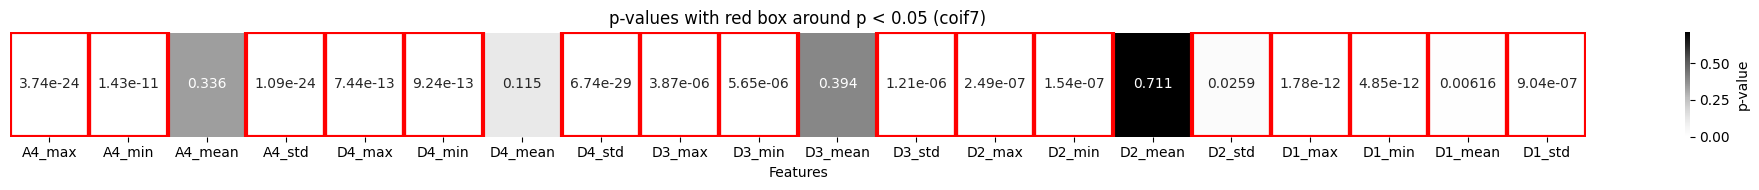

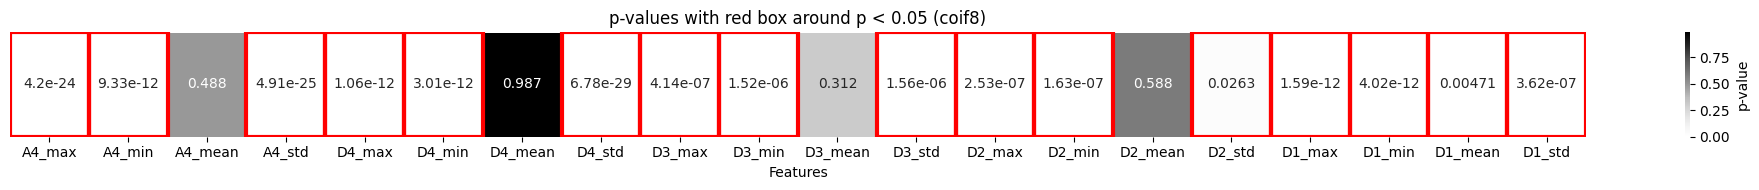

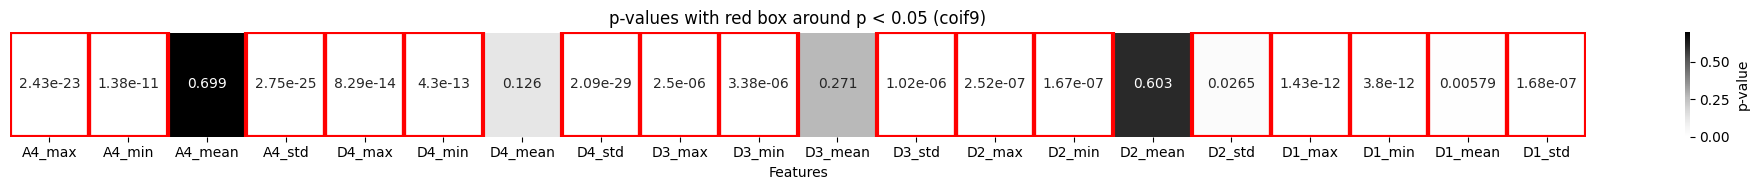

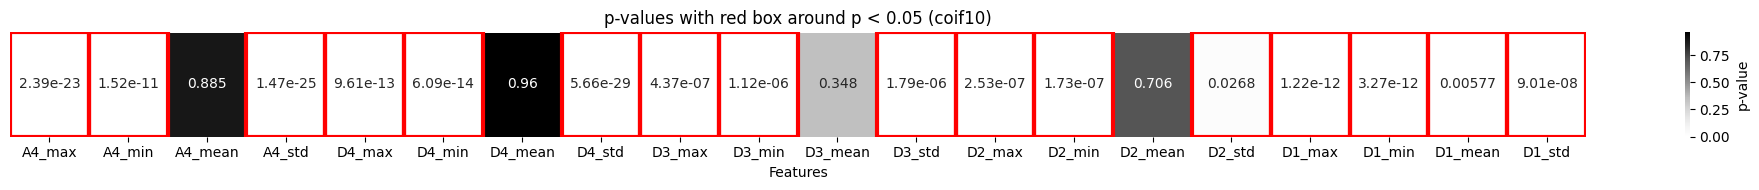

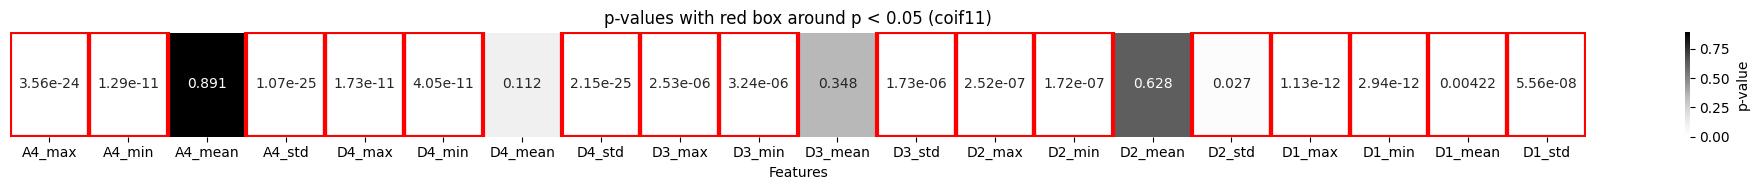

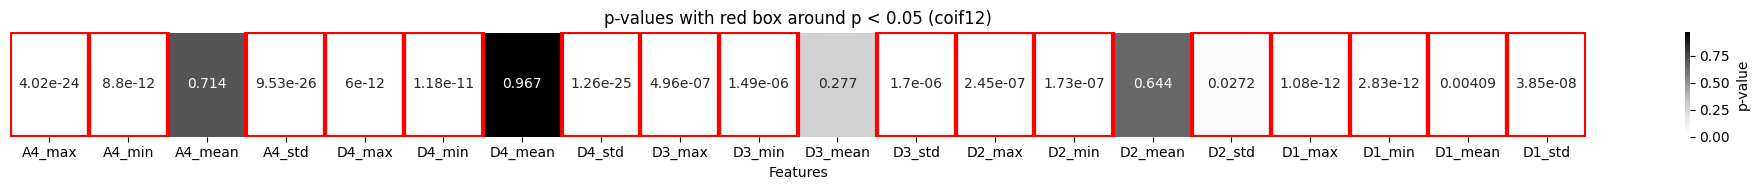

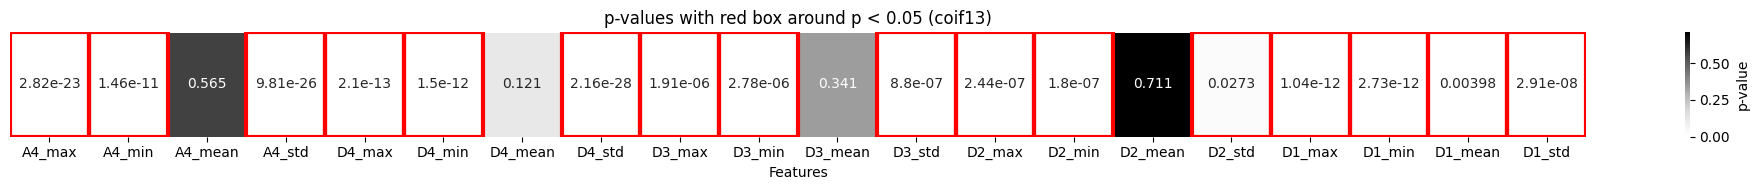

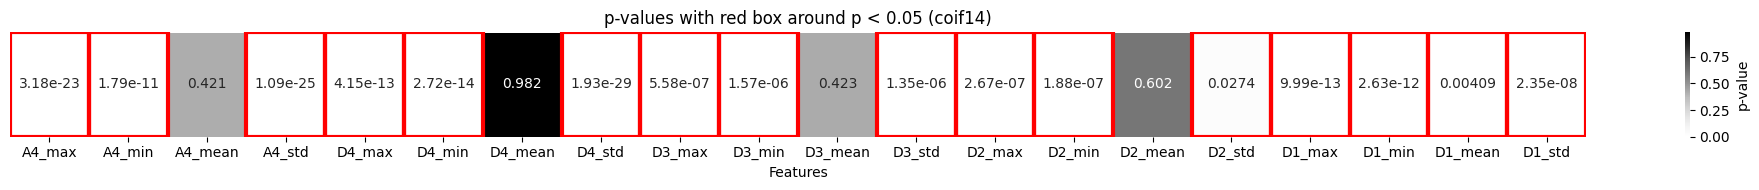

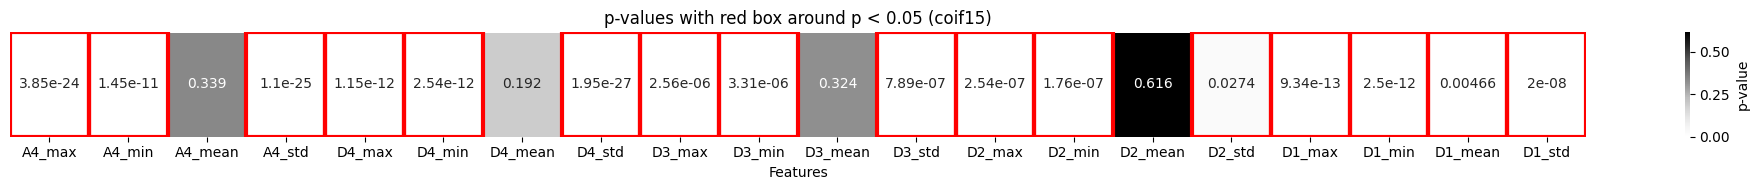

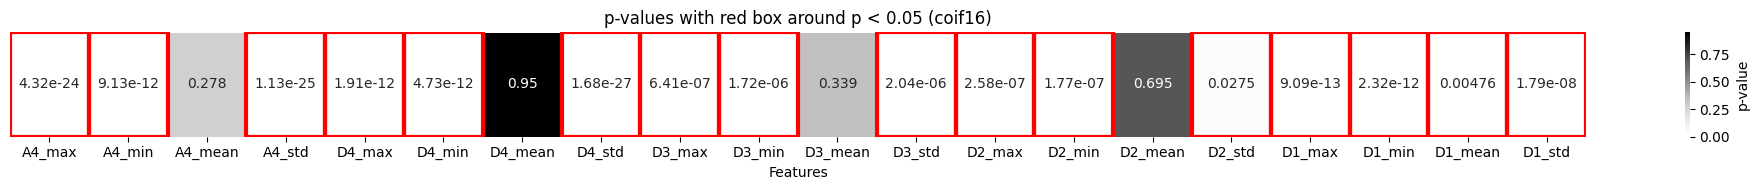

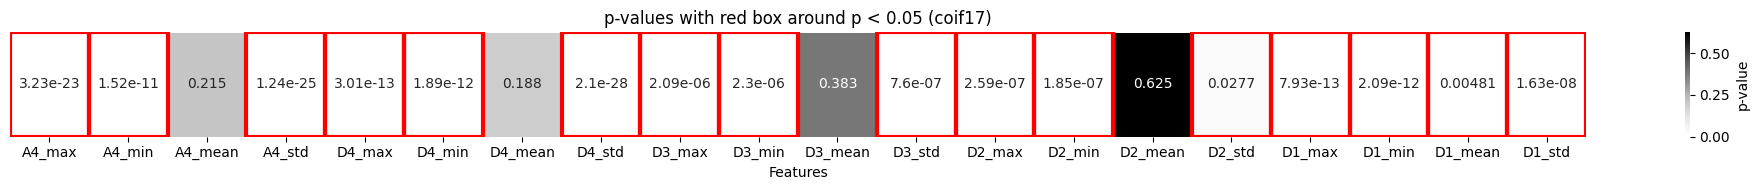

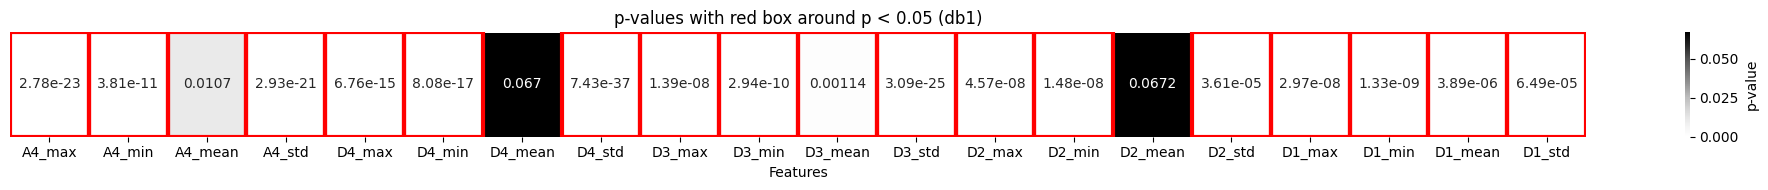

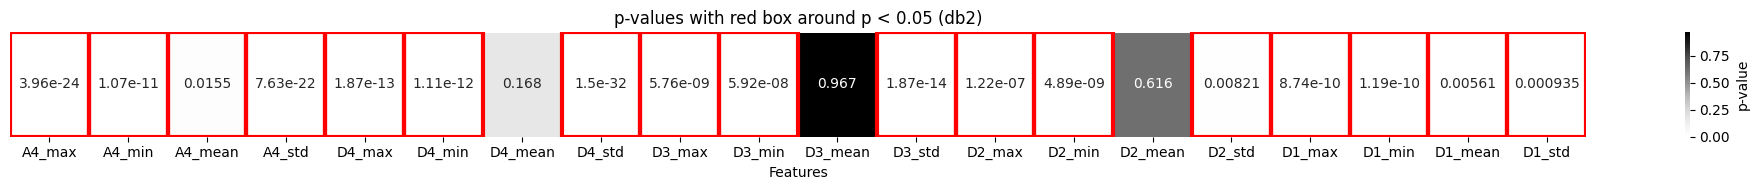

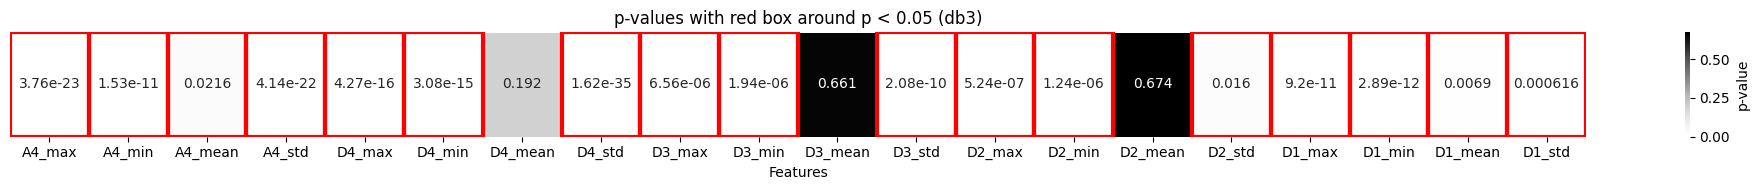

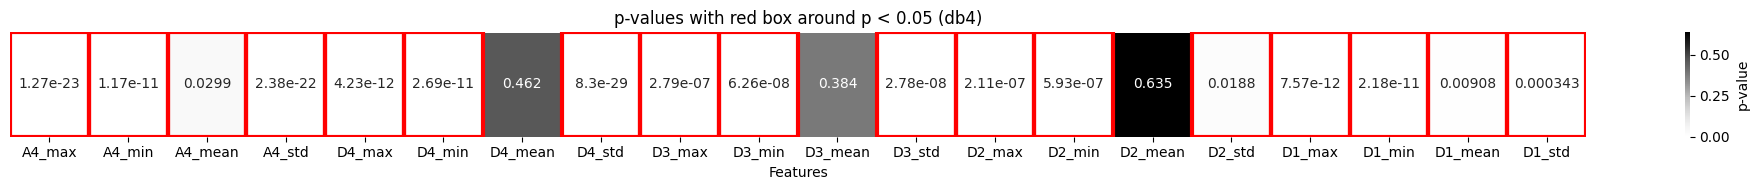

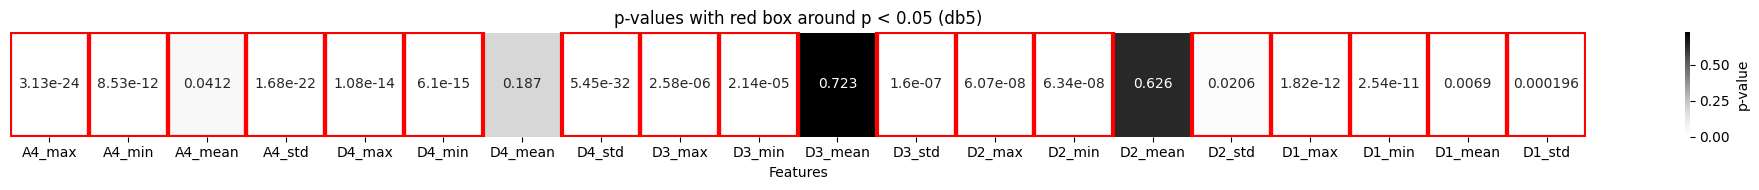

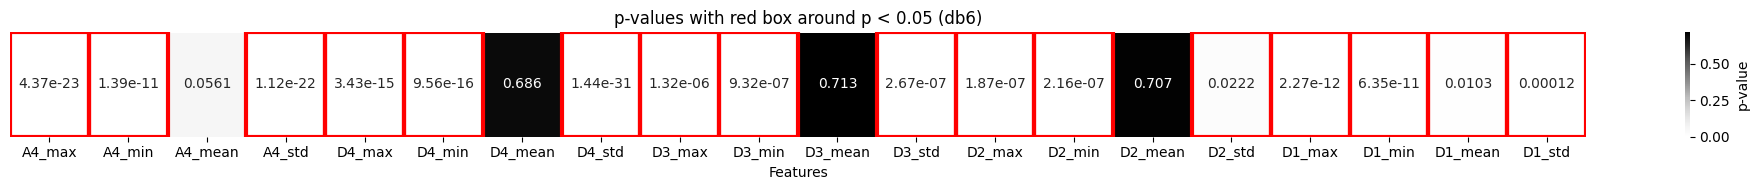

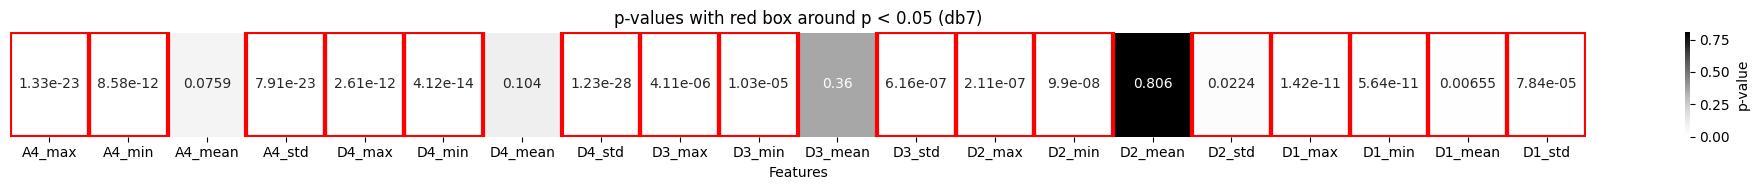

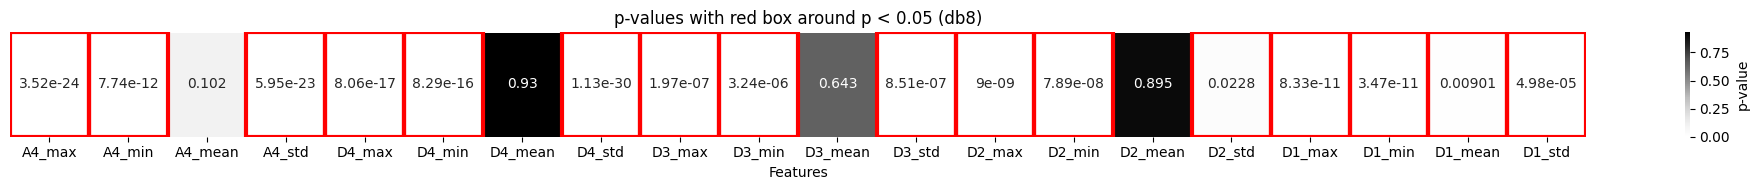

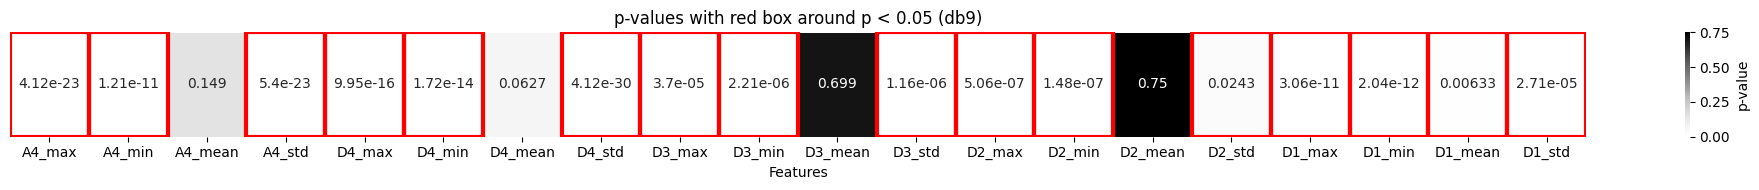

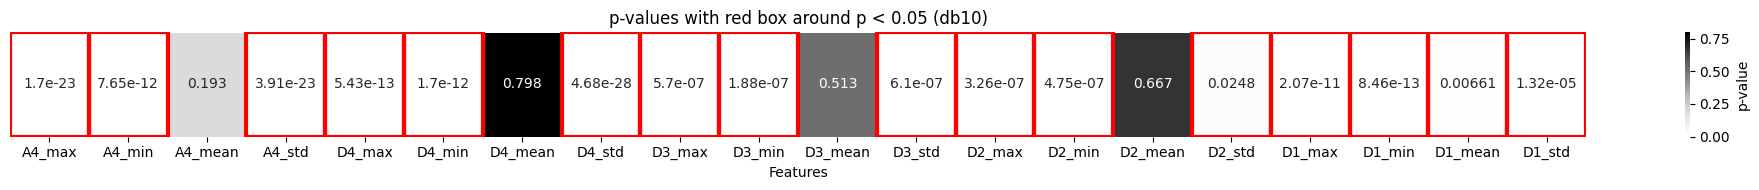

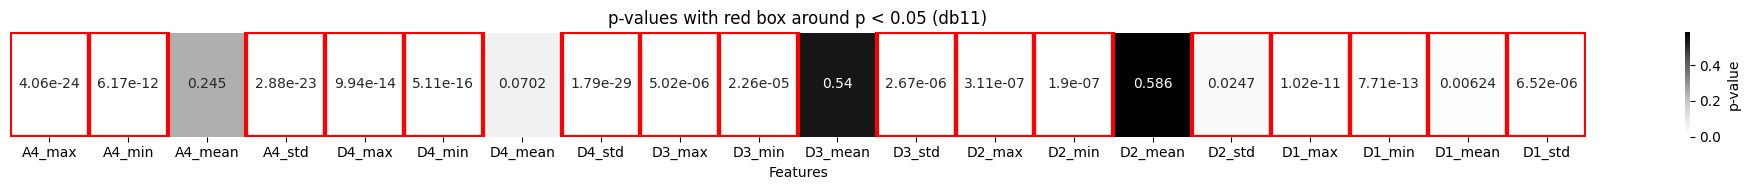

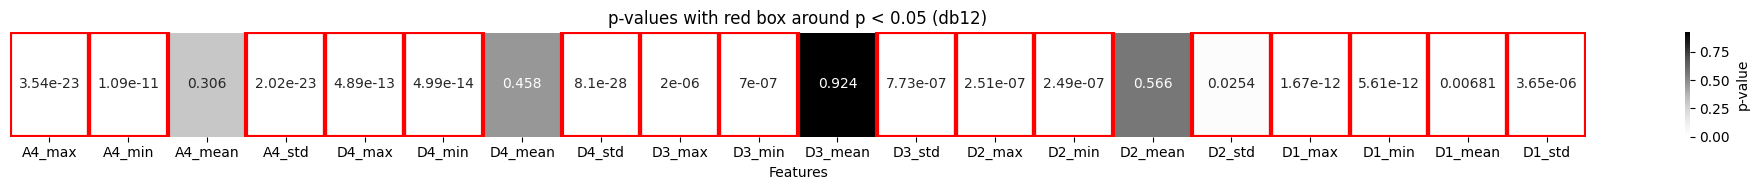

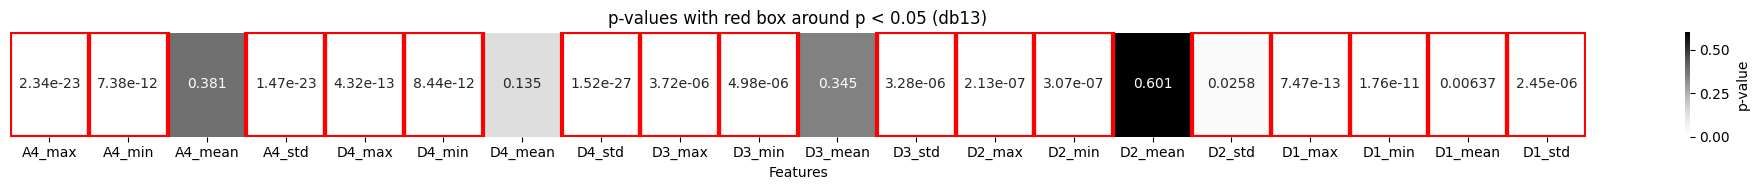

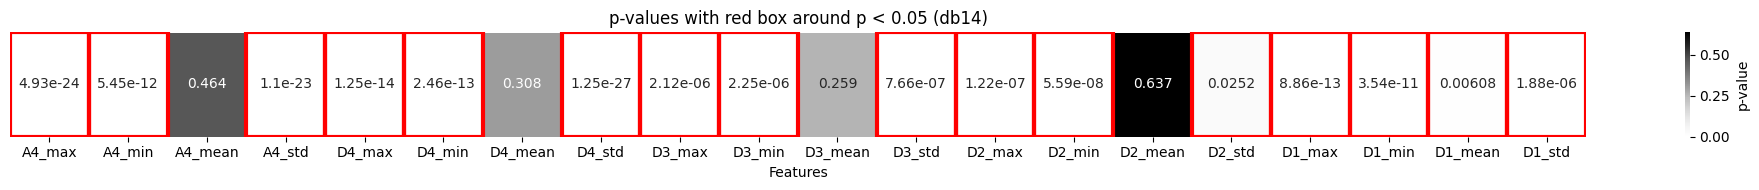

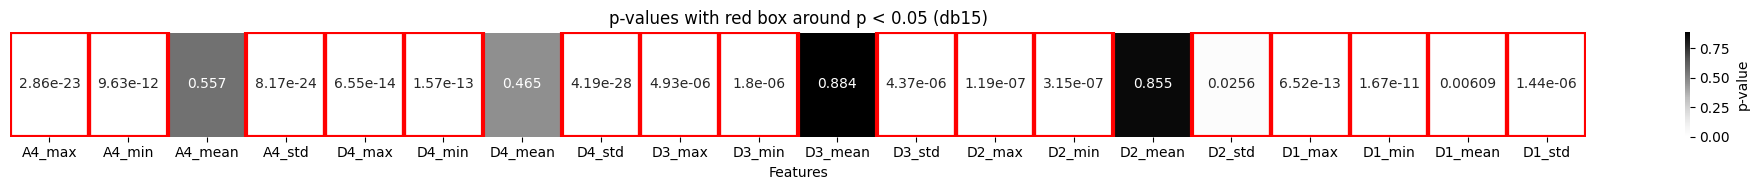

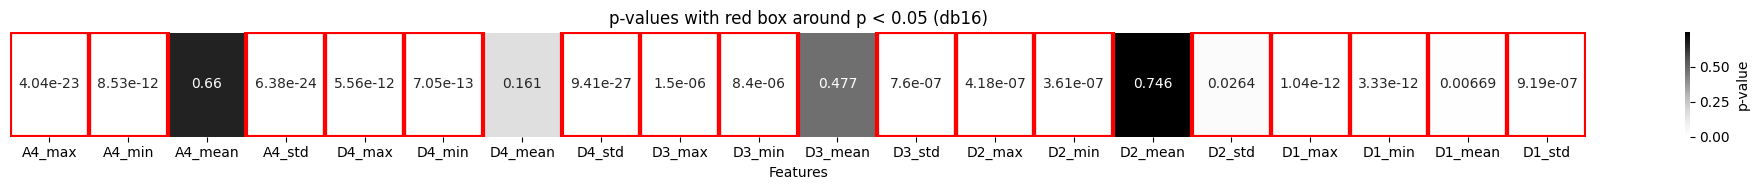

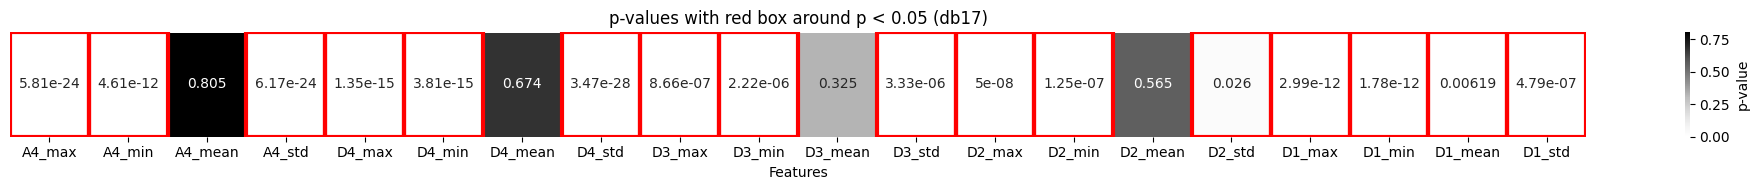

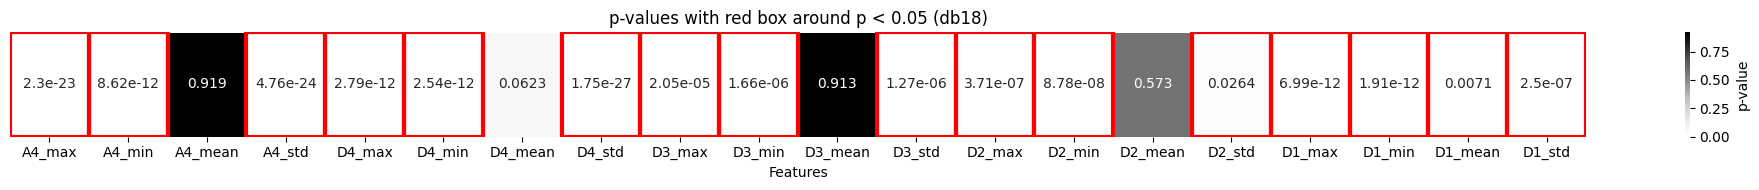

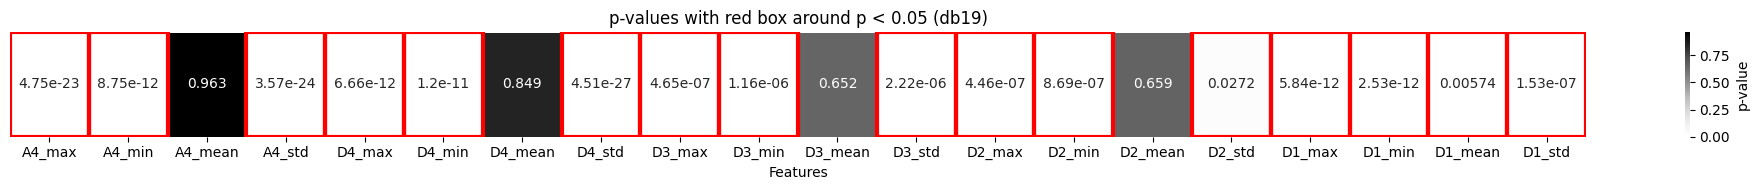

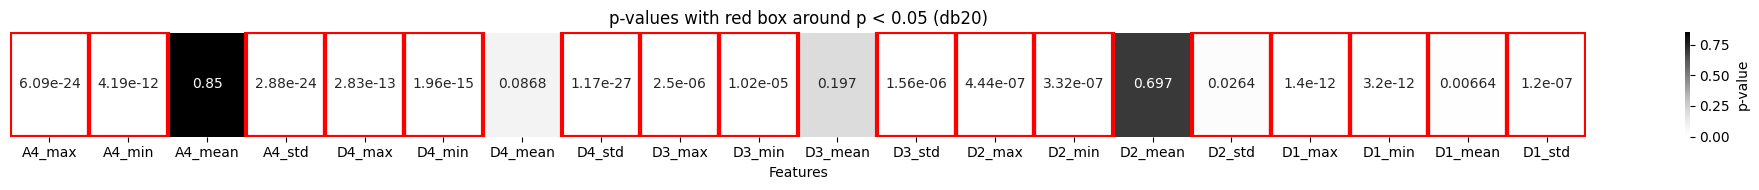

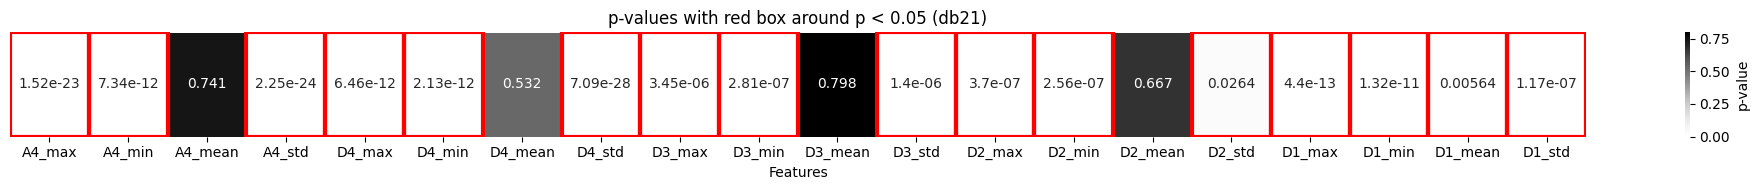

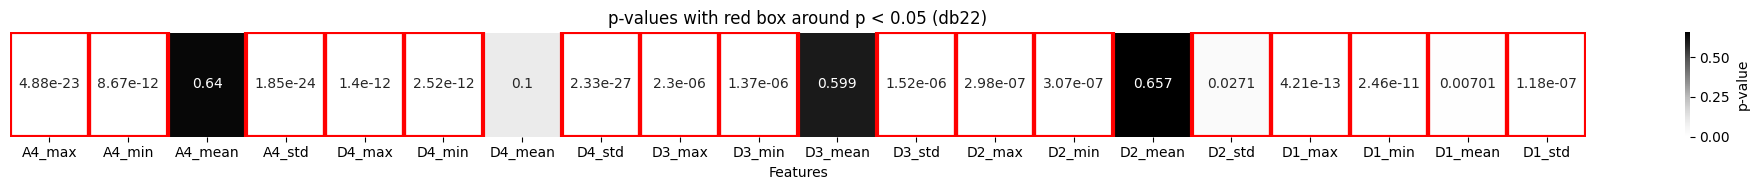

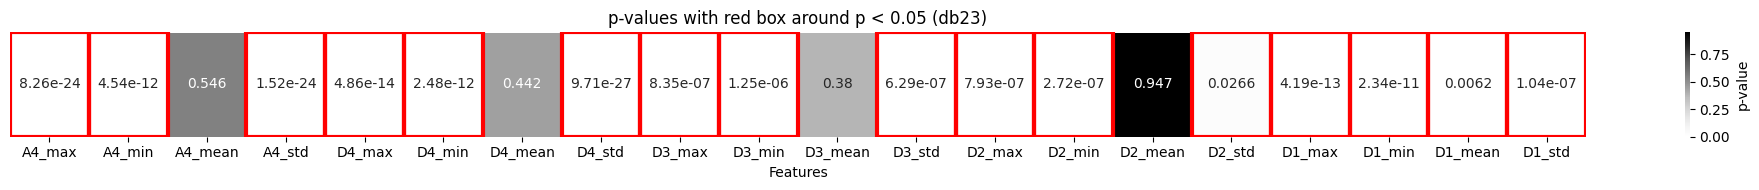

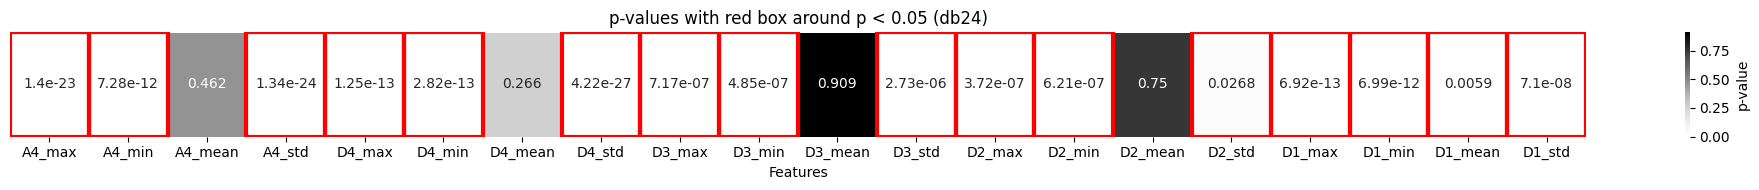

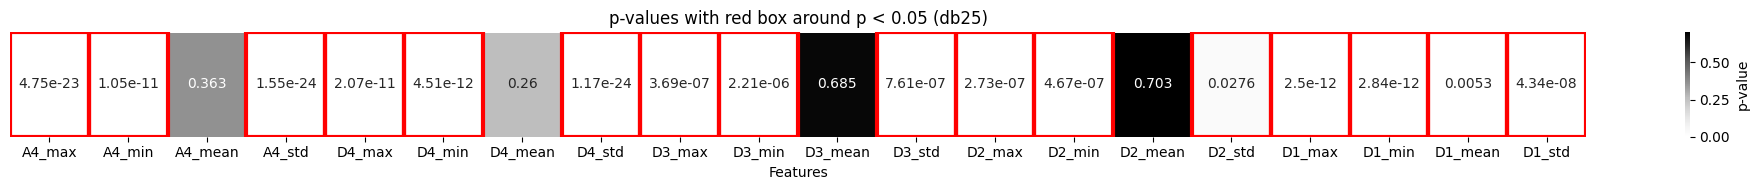

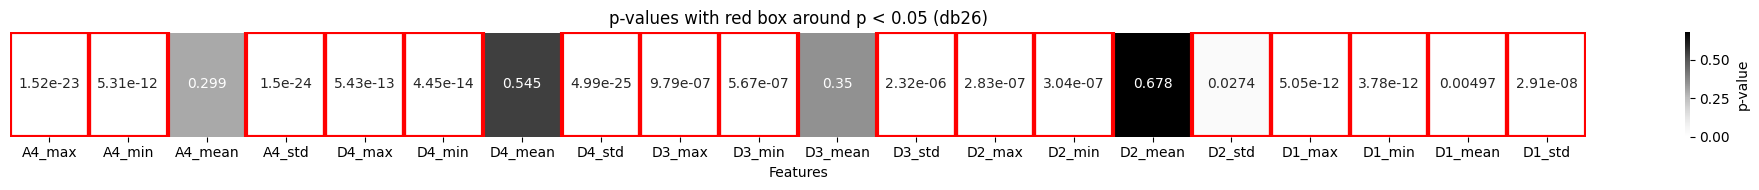

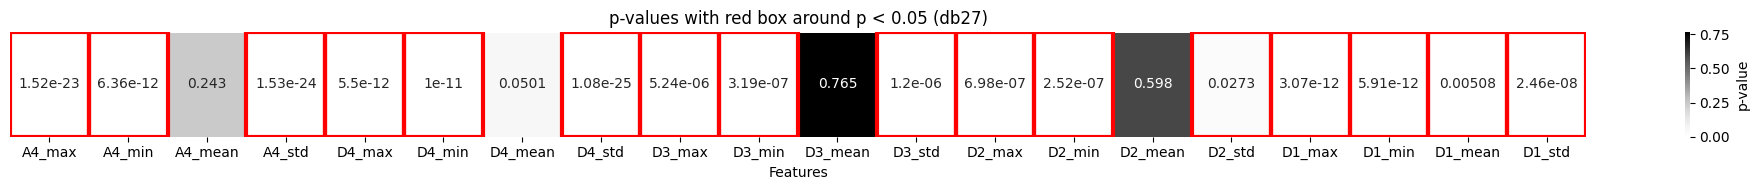

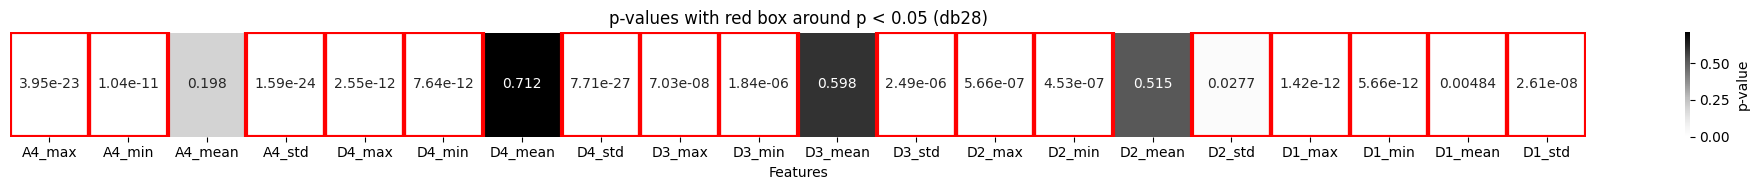

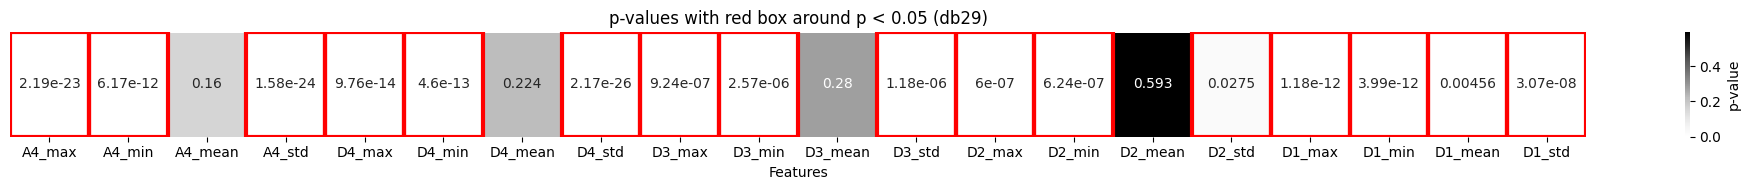

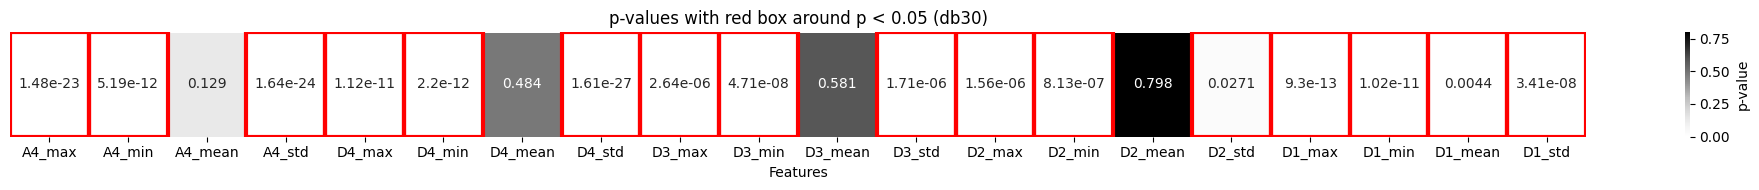

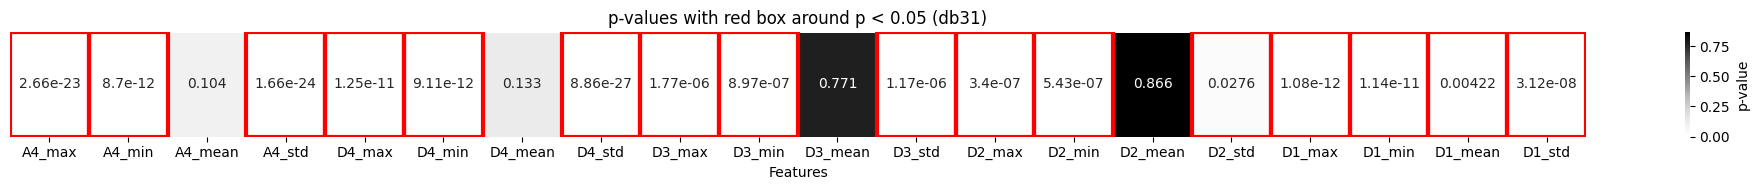

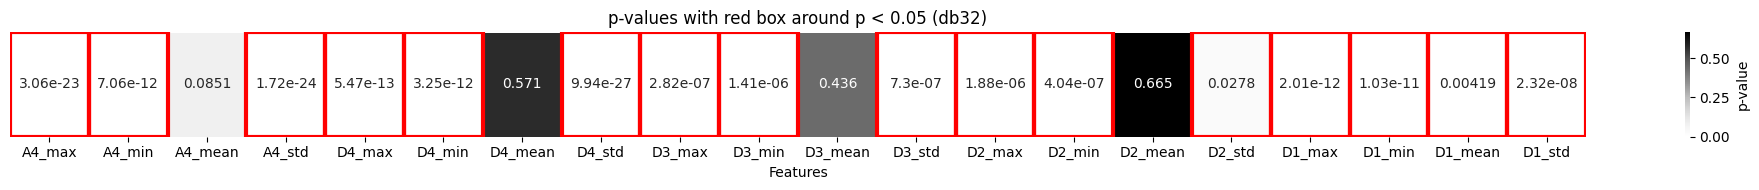

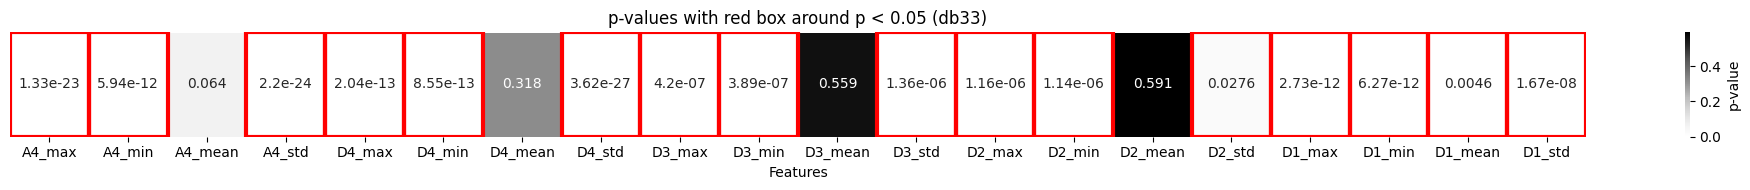

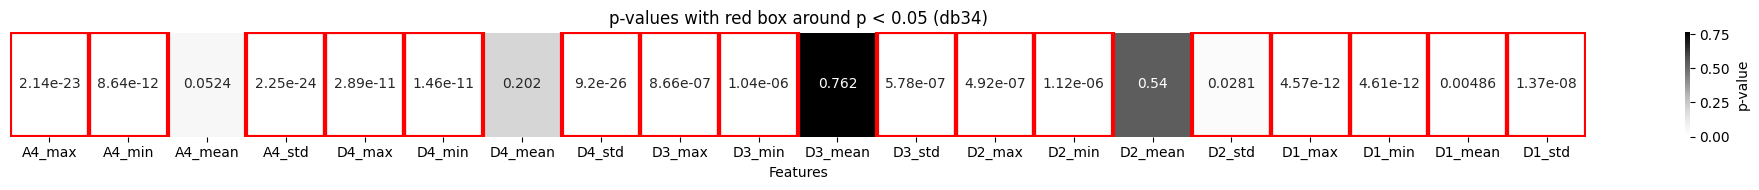

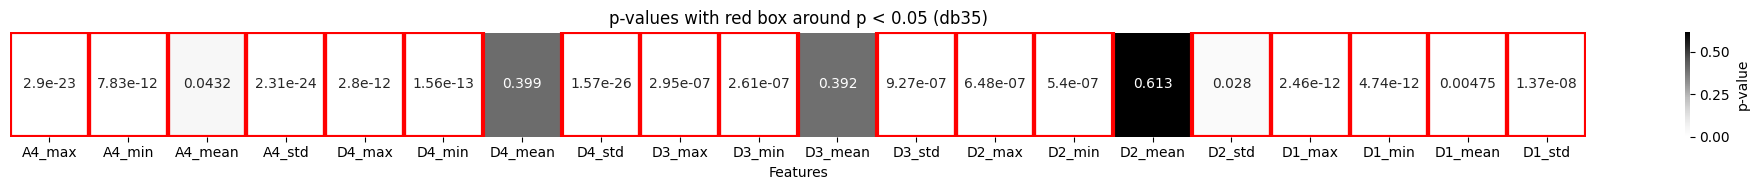

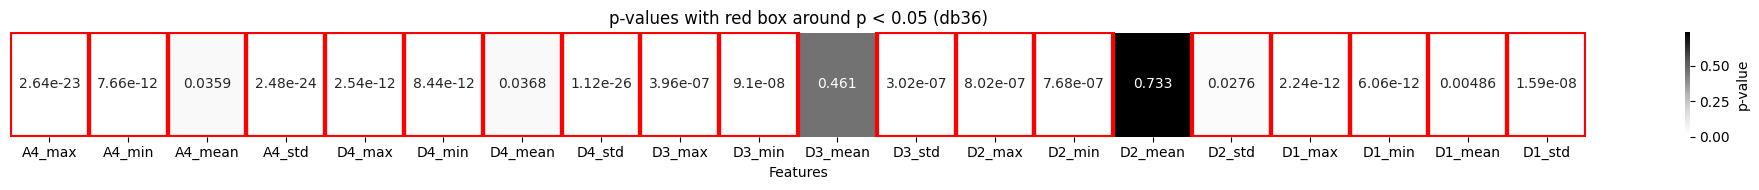

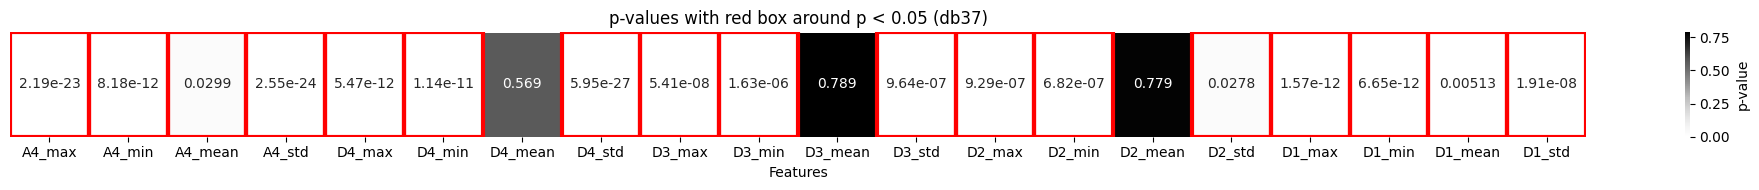

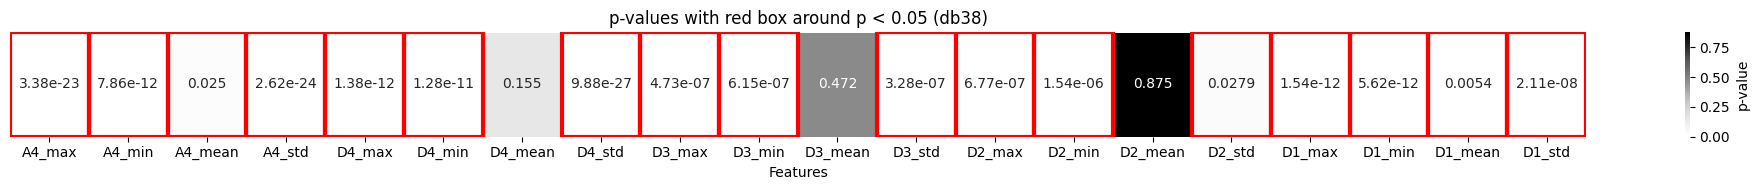

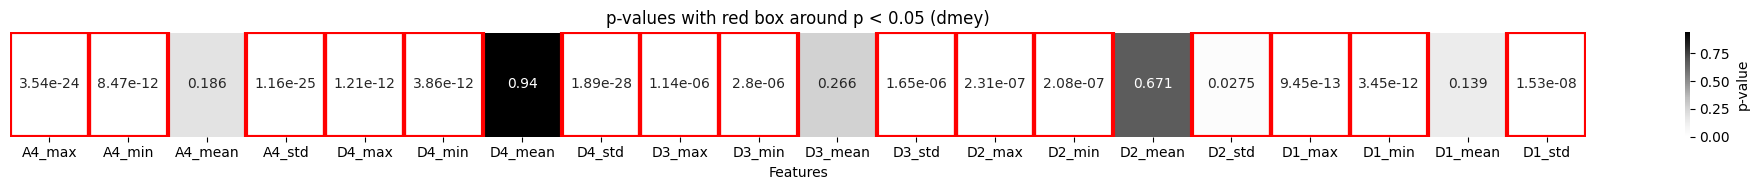

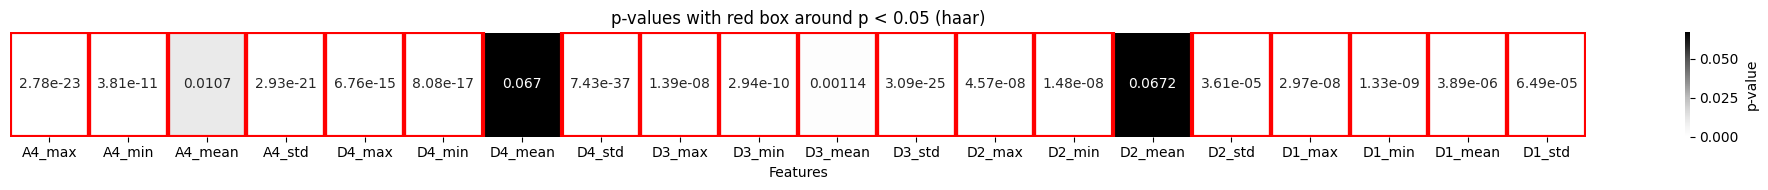

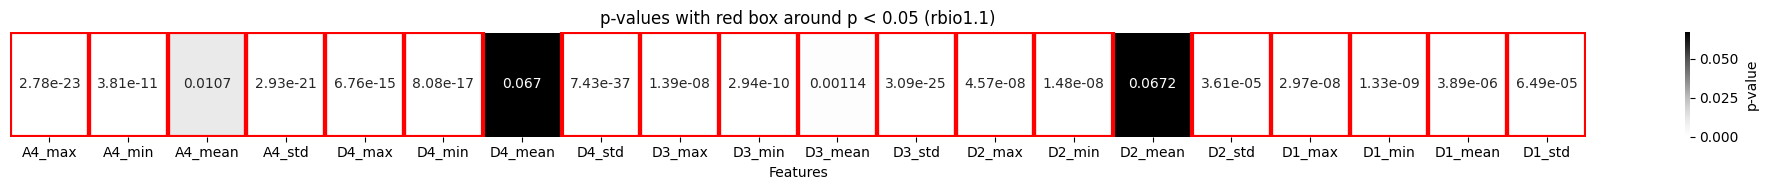

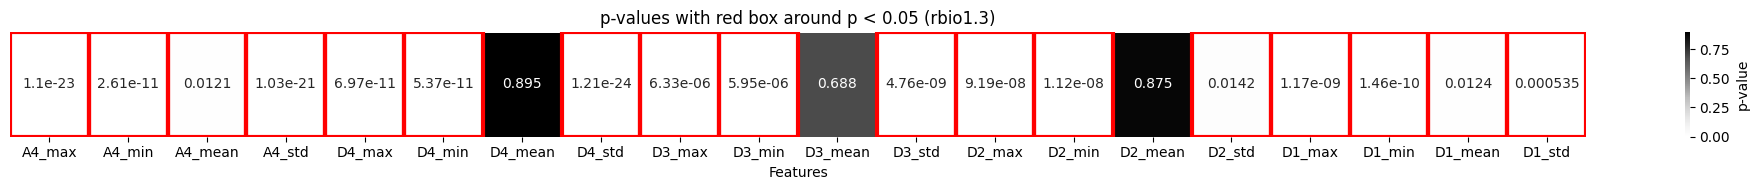

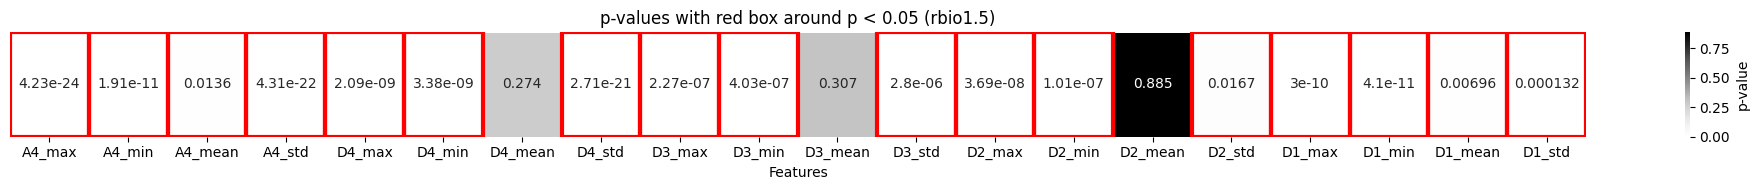

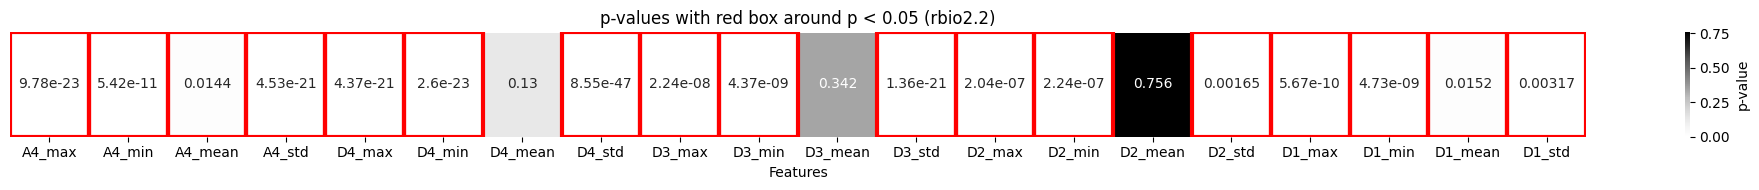

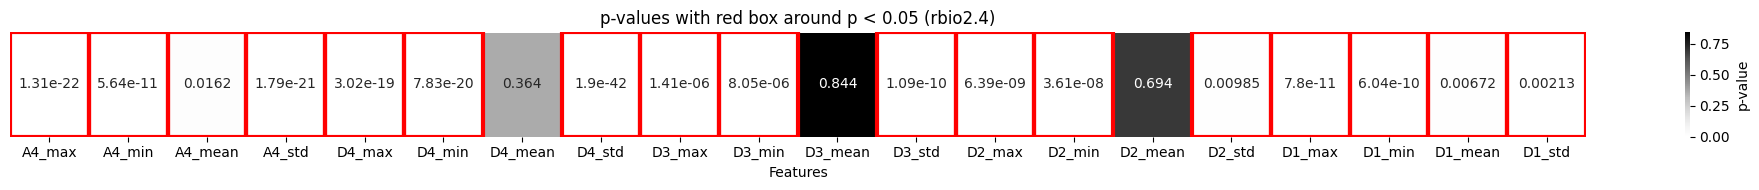

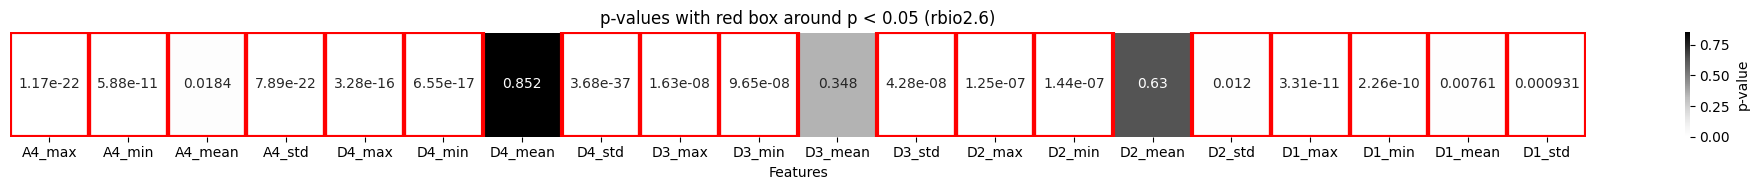

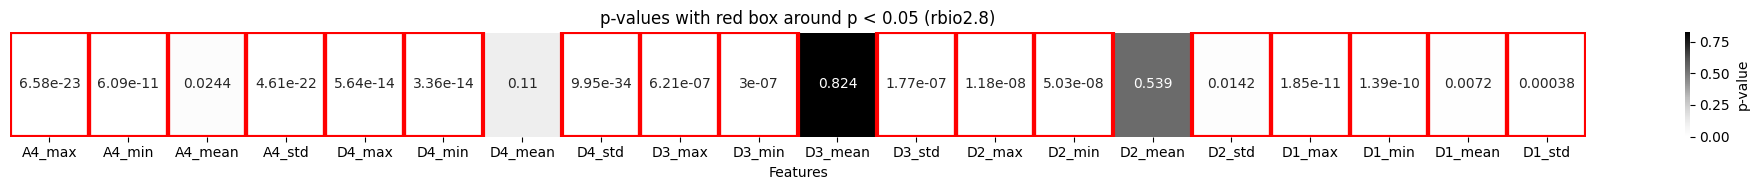

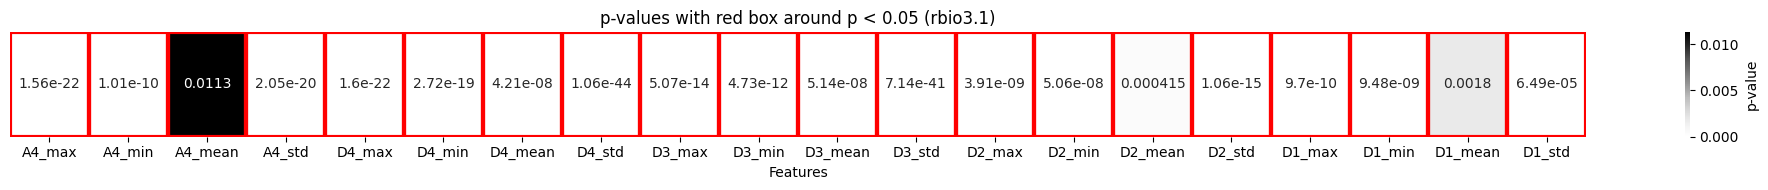

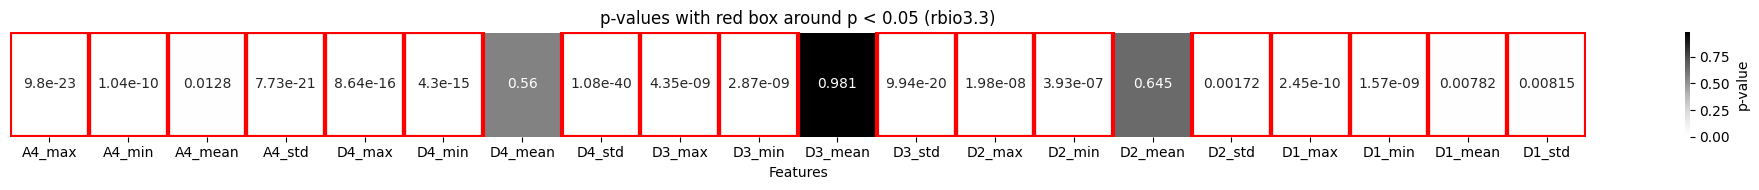

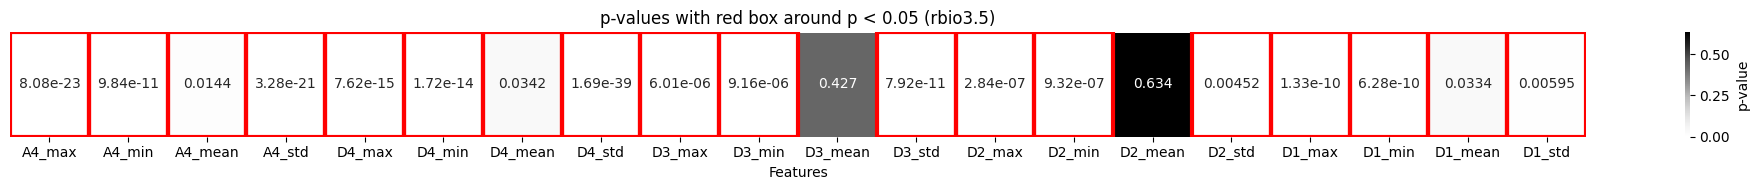

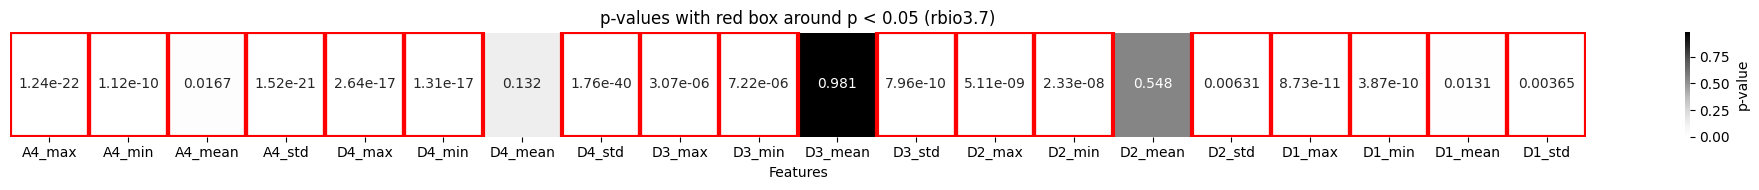

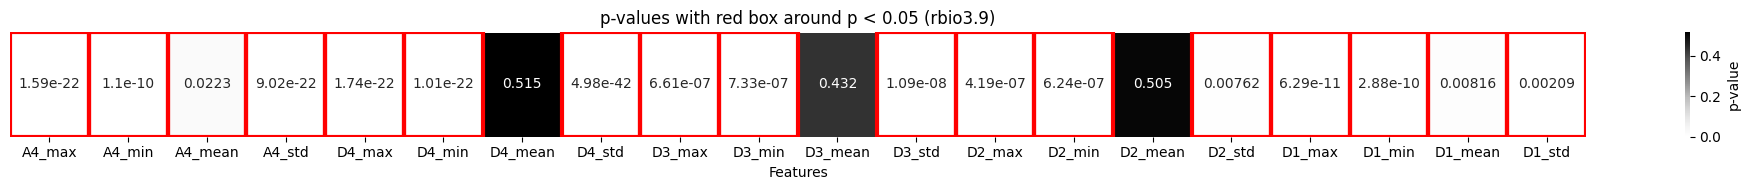

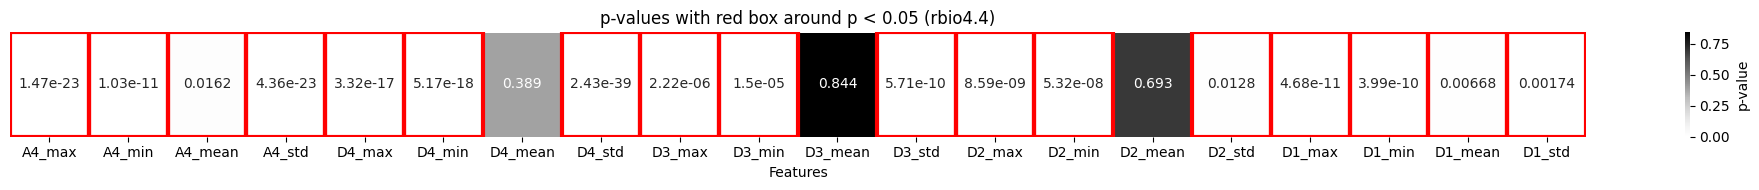

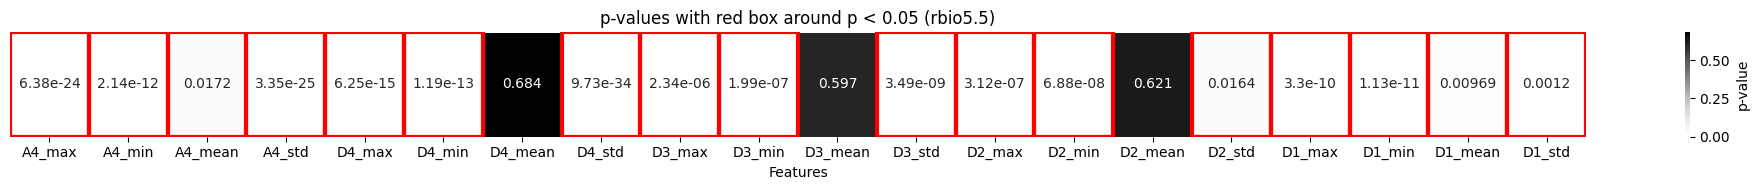

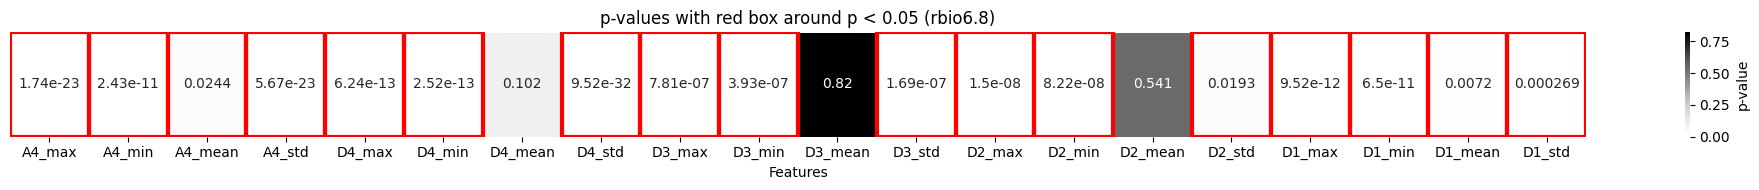

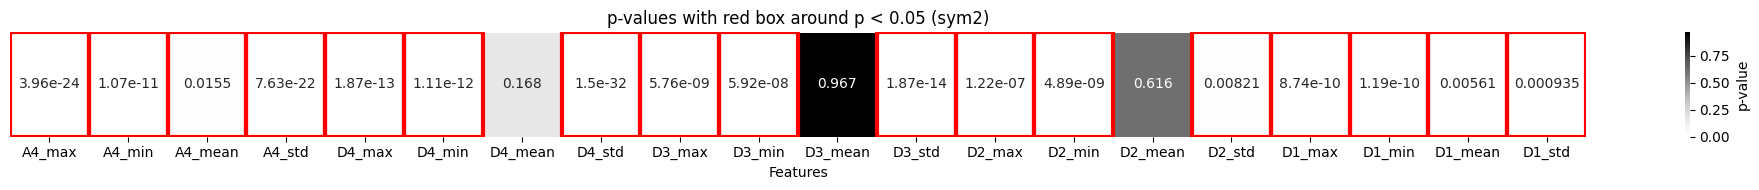

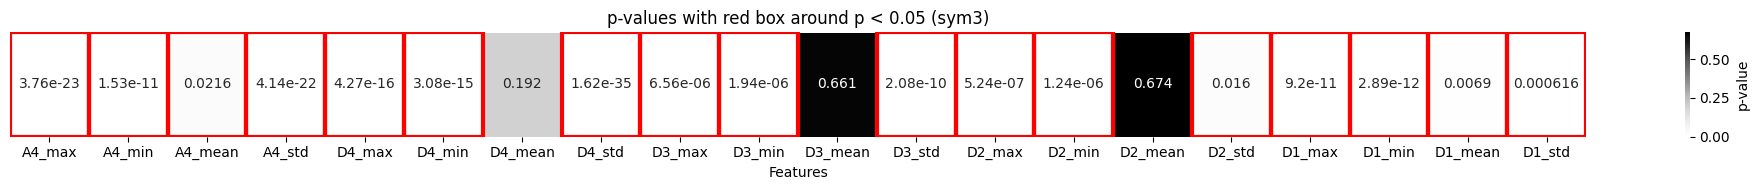

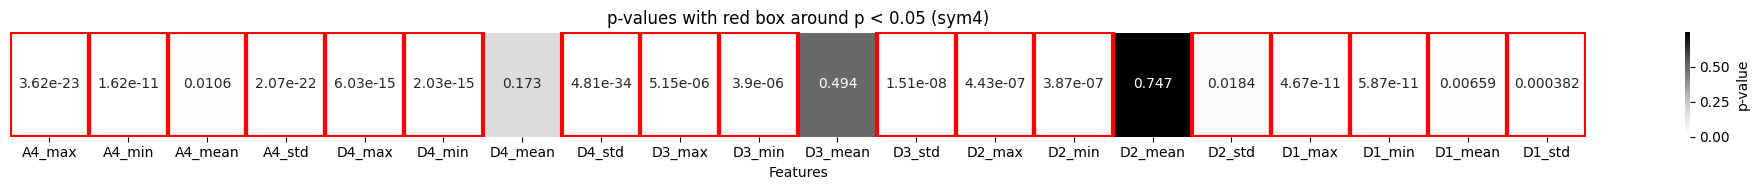

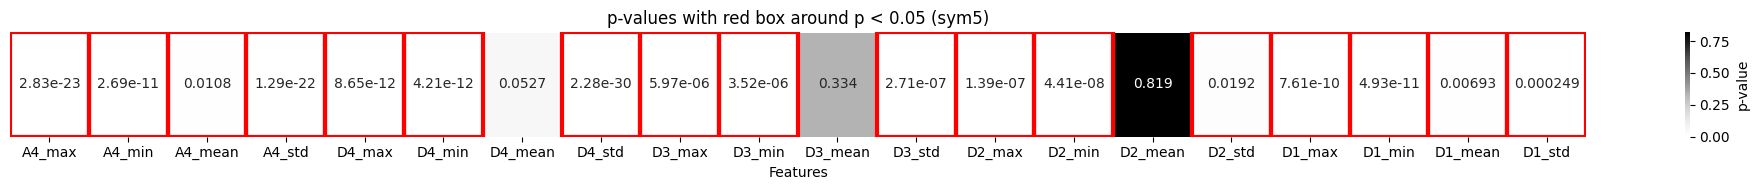

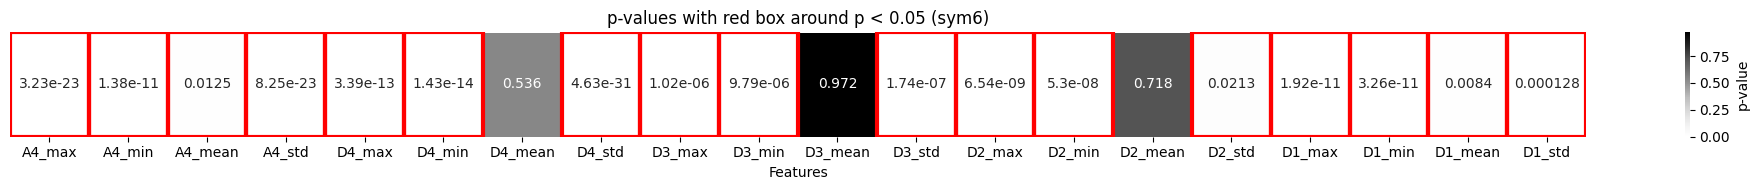

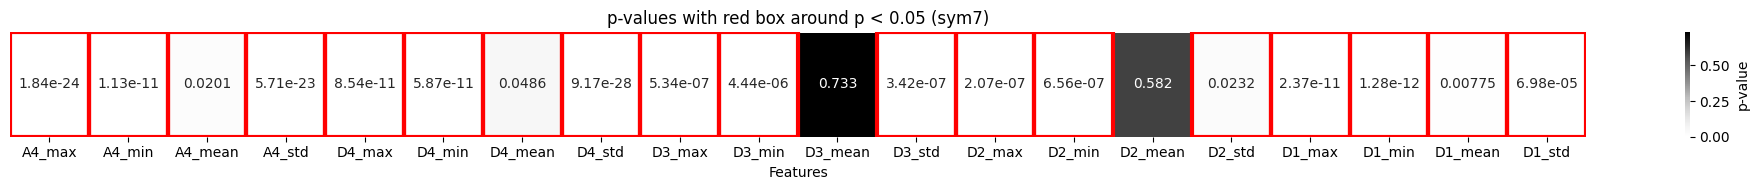

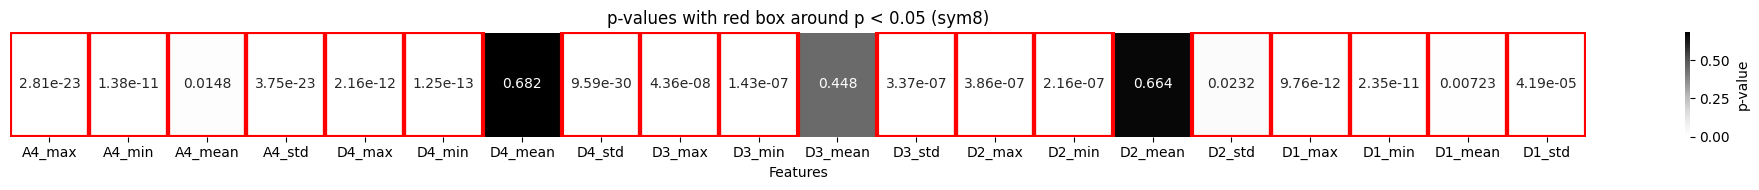

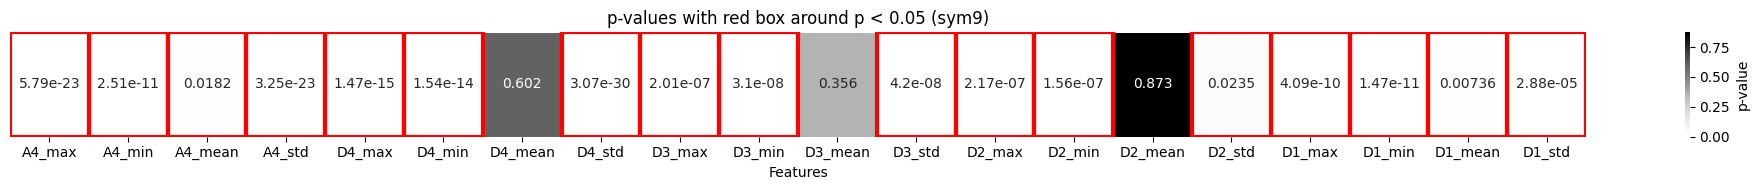

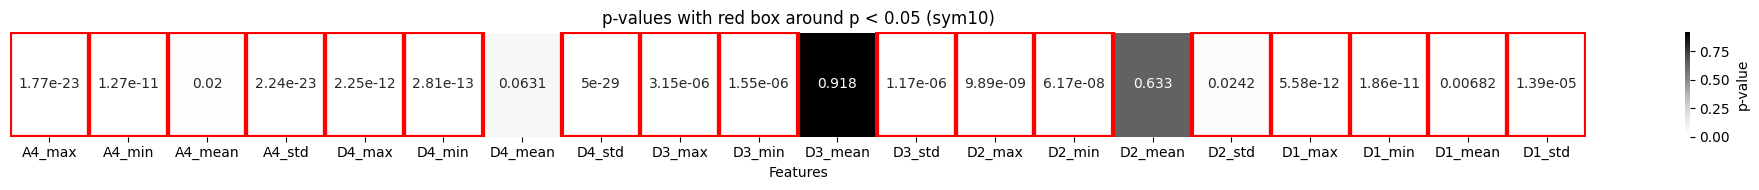

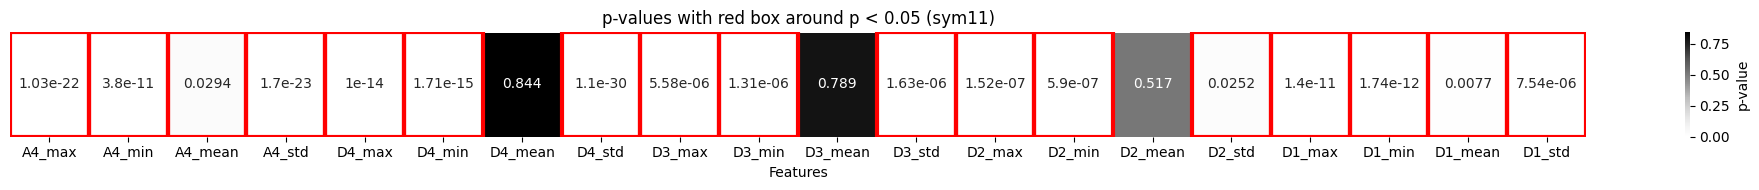

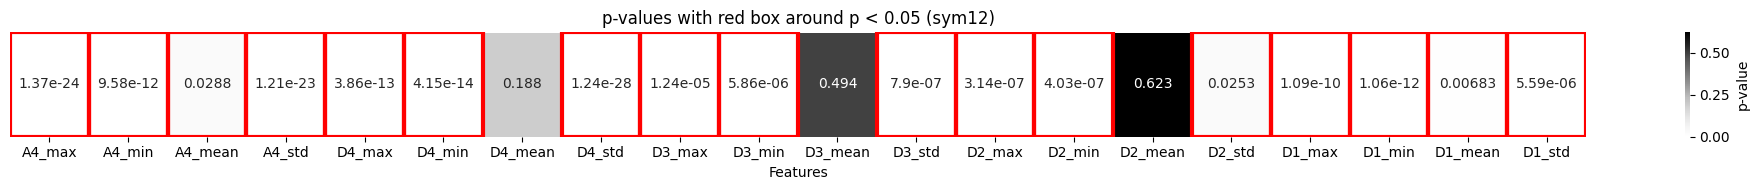

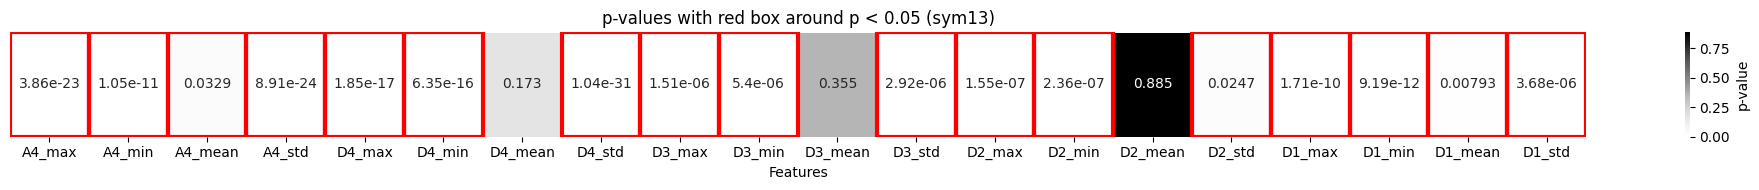

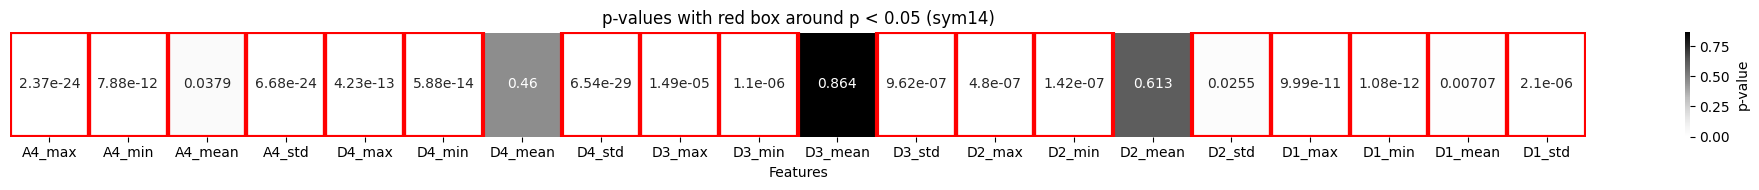

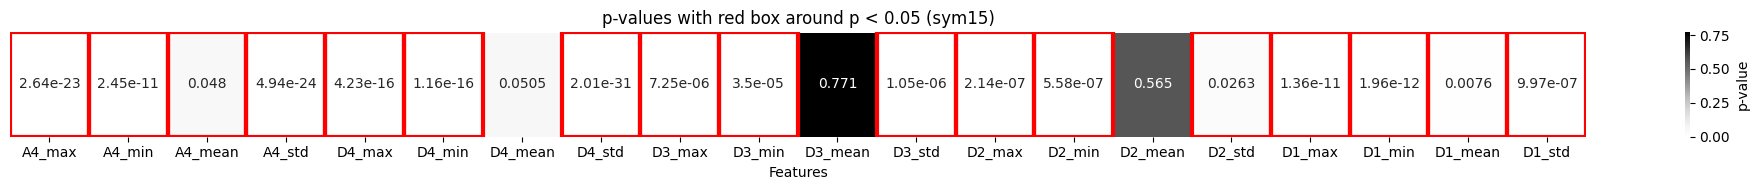

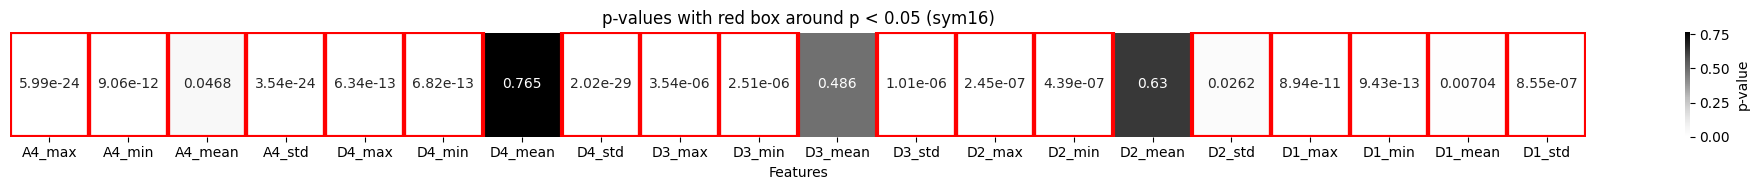

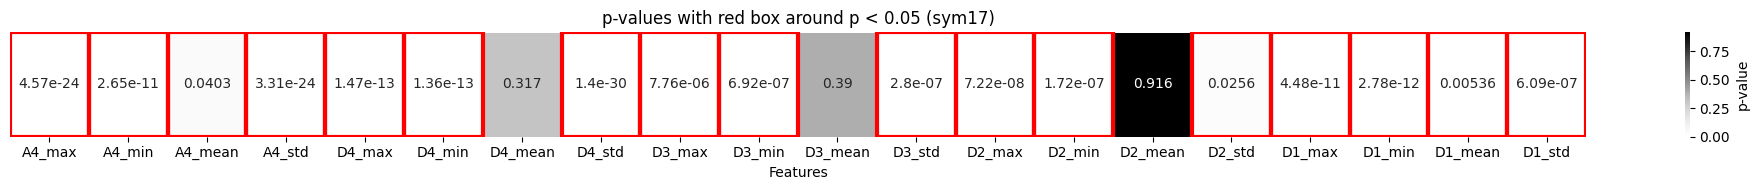

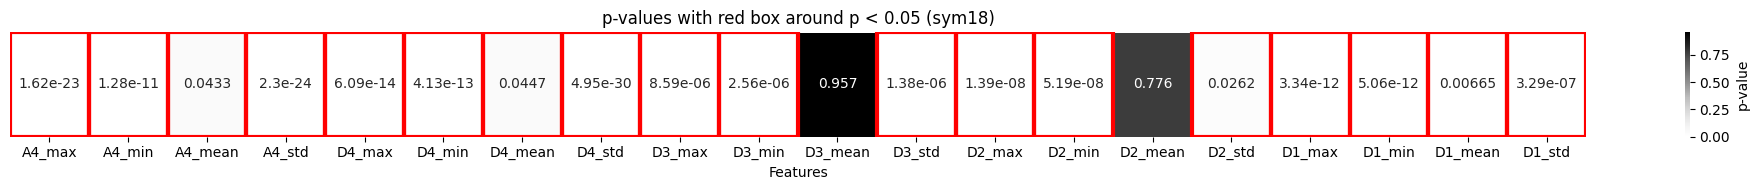

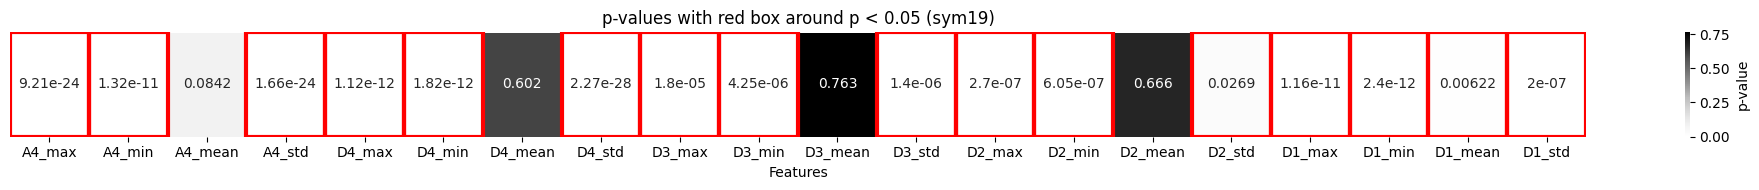

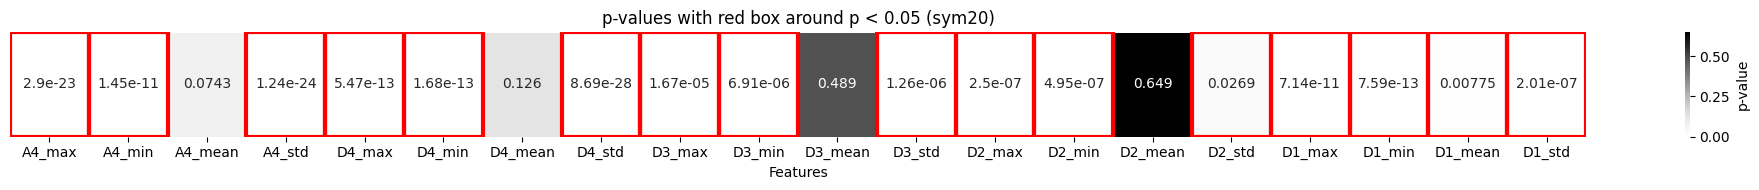

In [50]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

cols = ["A4_max","A4_min","A4_mean","A4_std","D4_max","D4_min","D4_mean","D4_std",
        "D3_max","D3_min","D3_mean","D3_std","D2_max","D2_min","D2_mean","D2_std",
        "D1_max","D1_min","D1_mean","D1_std"]

for i in range(len(train_dfs)):
    df1 = train_dfs[i]
    df2 = test_dfs[i]

    # Calculate p-values column-wise
    p_values = {col: ttest_ind(df1[col], df2[col], equal_var=False)[1] for col in cols}
    p_values_df = pd.DataFrame([p_values])

    # Create the plot
    plt.figure(figsize=(20, 2))

    # Plot heatmap of p-values in grayscale
    sns.heatmap(
        p_values_df,
        annot=True,
        fmt=".3g",
        cmap='Greys',
        cbar_kws={'label': 'p-value'},
        linewidths=0.5
    )

    # Highlight cells with p < 0.05 with red rectangles
    for y in range(p_values_df.shape[0]):
        for x in range(p_values_df.shape[1]):
            if p_values_df.iloc[y, x] < 0.05:
                plt.gca().add_patch(plt.Rectangle((x, y), 1, 1, fill=False, edgecolor='red', lw=3))

    plt.title(f"p-values with red box around p < 0.05 ({wavelet_list[i]})")
    plt.xlabel("Features")
    plt.yticks([])  # Hide y-axis since only one row
    plt.tight_layout()
    plt.show()


In [62]:
%pip install pytables

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement pytables (from versions: none)
ERROR: No matching distribution found for pytables

[notice] A new release of pip available: 22.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [65]:
import os

def save_dfs(train_dfs, test_dfs, output_dir="saved_dfs"):
    os.makedirs(output_dir, exist_ok=True)

    for i, (train_df, test_df) in enumerate(zip(train_dfs, test_dfs), start=1):
        train_path = os.path.join(output_dir, f"train_df_{i}.csv")
        test_path = os.path.join(output_dir, f"test_df_{i}.csv")

        train_df.to_csv(train_path, index=False)
        test_df.to_csv(test_path, index=False)

    print(f"Saved {len(train_dfs)} train and test DataFrames to '{output_dir}' folder.")

# Usage example:
save_dfs(train_dfs, test_dfs)



Saved 106 train and test DataFrames to 'saved_dfs' folder.


In [59]:
import optuna
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
import gc

def run_nn_pipeline_with_optuna(train_df, test_df, n_splits=5, epochs=50, batch_size=64, n_trials=30):
    train_df = train_df.drop('wavelet', axis=1, errors='ignore')
    test_df = test_df.drop('wavelet', axis=1, errors='ignore')

    y_train = train_df['label'].values
    y_test = test_df['label'].values
    X_train = train_df.drop('label', axis=1).values
    X_test = test_df.drop('label', axis=1).values

    # Log-transform then scale
    X_train = np.log1p(X_train)
    X_test = np.log1p(X_test)
    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    class MetaNN(nn.Module):
        def __init__(self, input_dim, hidden_units, dropout):
            super().__init__()
            layers = []
            current_dim = input_dim
            for units in hidden_units:
                layers.append(nn.Linear(current_dim, units))
                layers.append(nn.ReLU())
                layers.append(nn.Dropout(dropout))
                current_dim = units
            layers.append(nn.Linear(current_dim, 1))
            self.net = nn.Sequential(*layers)

        def forward(self, x):
            return self.net(x)

    n_pos = np.sum(y_train == 1)
    n_neg = np.sum(y_train == 0)
    pos_weight = torch.tensor(n_neg / n_pos).to(device)

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    def objective(trial):
        lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
        dropout = trial.suggest_float("dropout", 0.1, 0.5)
        n_layers = trial.suggest_int("n_layers", 2, 5)
        hidden_units = [trial.suggest_int(f"n_units_l{i}", 8, 128) for i in range(n_layers)]

        val_aucs = []

        for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
            X_tr, y_tr = X_train_t[train_idx], y_train_t[train_idx]
            X_val, y_val = X_train_t[val_idx], y_train_t[val_idx]

            train_ds = TensorDataset(X_tr, y_tr)
            val_ds = TensorDataset(X_val, y_val)

            train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
            val_loader = DataLoader(val_ds, batch_size=batch_size)

            model = MetaNN(X_train.shape[1], hidden_units, dropout).to(device)
            optimizer = optim.Adam(model.parameters(), lr=lr)
            criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

            best_val_auc = 0
            best_state = None

            for epoch in range(epochs):
                model.train()
                for xb, yb in train_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    optimizer.zero_grad()
                    preds = model(xb)
                    loss = criterion(preds, yb)
                    loss.backward()
                    optimizer.step()

                model.eval()
                val_preds = []
                val_labels = []
                with torch.no_grad():
                    for xb, yb in val_loader:
                        xb, yb = xb.to(device), yb.to(device)
                        preds = model(xb)
                        val_preds.append(torch.sigmoid(preds).cpu())
                        val_labels.append(yb.cpu())
                val_preds = torch.cat(val_preds).numpy().ravel()
                val_labels = torch.cat(val_labels).numpy().ravel()

                val_auc = roc_auc_score(val_labels, val_preds)
                if val_auc > best_val_auc:
                    best_val_auc = val_auc
                    best_state = model.state_dict()

                # Unique step across folds & epochs to avoid Optuna warnings
                step = fold * epochs + epoch
                trial.report(val_auc, step)
                if trial.should_prune():
                    raise optuna.exceptions.TrialPruned()

            model.load_state_dict(best_state)

            val_aucs.append(best_val_auc)

            del model, optimizer, criterion, train_loader, val_loader
            torch.cuda.empty_cache()
            gc.collect()

        return np.mean(val_aucs)

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials)

    print("Best trial:")
    trial = study.best_trial
    print(f"  AUC: {trial.value:.4f}")
    print("  Params:")
    for key, value in trial.params.items():
        print(f"    {key}: {value}")

    # Train final model on full train data using best params
    best_lr = trial.params["lr"]
    best_dropout = trial.params["dropout"]
    n_layers = trial.params["n_layers"]
    best_hidden_units = [trial.params[f"n_units_l{i}"] for i in range(n_layers)]

    full_dataset = TensorDataset(X_train_t, y_train_t)
    full_loader = DataLoader(full_dataset, batch_size=batch_size, shuffle=True)

    final_model = MetaNN(X_train.shape[1], best_hidden_units, best_dropout).to(device)
    optimizer = optim.Adam(final_model.parameters(), lr=best_lr)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    for epoch in range(epochs):
        final_model.train()
        for xb, yb in full_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = final_model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

    final_model.eval()
    X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
    with torch.no_grad():
        test_preds_logits = final_model(X_test_t)
        test_preds = torch.sigmoid(test_preds_logits).cpu().numpy().ravel()
        test_pred_class = (test_preds > 0.5).astype(int)

    cm = confusion_matrix(y_test, test_pred_class)
    report = classification_report(y_test, test_pred_class, digits=4)
    auc = roc_auc_score(y_test, test_preds)

    print("=== Final Model Performance on Test Set ===")
    print(report)
    print(f"Test AUROC: {auc:.4f}")

    return cm, study

# Usage example (make sure train_dfs, test_dfs are your datasets):
for i, (train_df, test_df) in enumerate(zip(train_dfs, test_dfs)):
    print(f"\n=== Dataset {i+1} ===")
    cm, study = run_nn_pipeline_with_optuna(train_df, test_df, n_trials=20)
    print(f"Confusion matrix for dataset {i+1}:\n{cm}\n")
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()


[I 2025-07-01 14:29:46,569] A new study created in memory with name: no-name-f0bfd3b2-58fb-4a1e-b692-8c214cd57f42



=== Dataset 1 ===


[I 2025-07-01 14:30:27,838] Trial 0 finished with value: 0.5220794288921364 and parameters: {'lr': 2.4751766017553063e-05, 'dropout': 0.4912574714064061, 'n_layers': 5, 'n_units_l0': 74, 'n_units_l1': 15, 'n_units_l2': 70, 'n_units_l3': 84, 'n_units_l4': 119}. Best is trial 0 with value: 0.5220794288921364.
[I 2025-07-01 14:31:05,208] Trial 1 finished with value: 0.5571761744679476 and parameters: {'lr': 8.242208874052557e-05, 'dropout': 0.41871043332036717, 'n_layers': 4, 'n_units_l0': 117, 'n_units_l1': 118, 'n_units_l2': 14, 'n_units_l3': 91}. Best is trial 1 with value: 0.5571761744679476.
[I 2025-07-01 14:31:38,796] Trial 2 finished with value: 0.5539140775890301 and parameters: {'lr': 0.0021546157394007654, 'dropout': 0.23288706811360674, 'n_layers': 3, 'n_units_l0': 114, 'n_units_l1': 55, 'n_units_l2': 113}. Best is trial 1 with value: 0.5571761744679476.
[I 2025-07-01 14:32:15,617] Trial 3 finished with value: 0.5467245689515922 and parameters: {'lr': 0.00012617189684706618, 'd

KeyboardInterrupt: 